## Модели прогнозирования объема убоя Овцы и козы по Акмолинской области

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from pmdarima import auto_arima
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pylab import rcParams
from IPython.display import display
import math
from prophet import Prophet
pd.set_option('display.max_columns', 130)


import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter("ignore", category=InterpolationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

### Подготовка данных и EDA

In [2]:
df = pd.read_excel("Датасет по овцы и козы с регрессорами.xlsx")
df.sample(10)

,Регион,Период,Овцы и козы,Осадки,Поголовье: овцы и козы,Температура,Цена: Баранина
395,АТЫРАУСКАЯ ОБЛАСТЬ,2017-12,1993.32,15.8,542652,-4.016129,113.351492
1536,МАНГИСТАУСКАЯ ОБЛАСТЬ,2016-06,319.98,3.7,491301,24.616667,100.500600
950,ЖАМБЫЛСКАЯ ОБЛАСТЬ,2017-08,2634.49,2.5,3036888,23.361290,109.881819
934,ЖАМБЫЛСКАЯ ОБЛАСТЬ,2016-04,2488.66,54.8,3250508,13.116667,100.483154
6,АКМОЛИНСКАЯ ОБЛАСТЬ,2015-07,621.61,39.6,581065,19.180645,99.200000
400,АТЫРАУСКАЯ ОБЛАСТЬ,2018-05,707.47,1.1,751045,22.041935,116.306684
785,ГАСТАНА,2020-06,1.70,96.3,1205,19.243333,175.446913
261,АЛМАТИНСКАЯ ОБЛАСТЬ,2016-10,3623.34,60.0,3787410,5.293548,105.857552
1623,МАНГИСТАУСКАЯ ОБЛАСТЬ,2023-09,467.01,11.7,6639,20.100000,225.807245
152,АКТЮБИНСКАЯ ОБЛАСТЬ,2017-09,2126.11,12.7,1284928,15.550000,112.506766


In [3]:
df_akmola = df[df['Регион'] == 'АКМОЛИНСКАЯ ОБЛАСТЬ']
df_akmola = df_akmola.drop('Регион', axis = 'columns')
df_akmola.head()

,Период,Овцы и козы,Осадки,Поголовье: овцы и козы,Температура,Цена: Баранина
0,2015-01,602.28,9.8,470582,-12.490323,100.0
1,2015-02,636.18,9.8,524810,-10.192857,100.0
2,2015-03,740.73,8.3,562860,-5.870968,100.0
3,2015-04,690.81,8.8,599518,4.490000,99.2
4,2015-05,869.73,42.8,632220,14.574194,99.2


In [4]:
df_akmola = df_akmola.rename(columns={'Овцы и козы': 'Объем убоя: Овцы и козы'})
df_akmola.head()

,Период,Объем убоя: Овцы и козы,Осадки,Поголовье: овцы и козы,Температура,Цена: Баранина
0,2015-01,602.28,9.8,470582,-12.490323,100.0
1,2015-02,636.18,9.8,524810,-10.192857,100.0
2,2015-03,740.73,8.3,562860,-5.870968,100.0
3,2015-04,690.81,8.8,599518,4.490000,99.2
4,2015-05,869.73,42.8,632220,14.574194,99.2


In [5]:
df_akmola['Период'] = pd.to_datetime(df_akmola['Период'], format='%Y-%m')
df_akmola.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Период                   120 non-null    datetime64[ns]
 1   Объем убоя: Овцы и козы  120 non-null    float64       
 2   Осадки                   120 non-null    float64       
 3   Поголовье: овцы и козы   120 non-null    int64         
 4   Температура              120 non-null    float64       
 5   Цена: Баранина           120 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 6.6 KB


In [6]:
df_akmola.isna().sum()

Период                     0
Объем убоя: Овцы и козы    0
Осадки                     0
Поголовье: овцы и козы     0
Температура                0
Цена: Баранина             0
dtype: int64

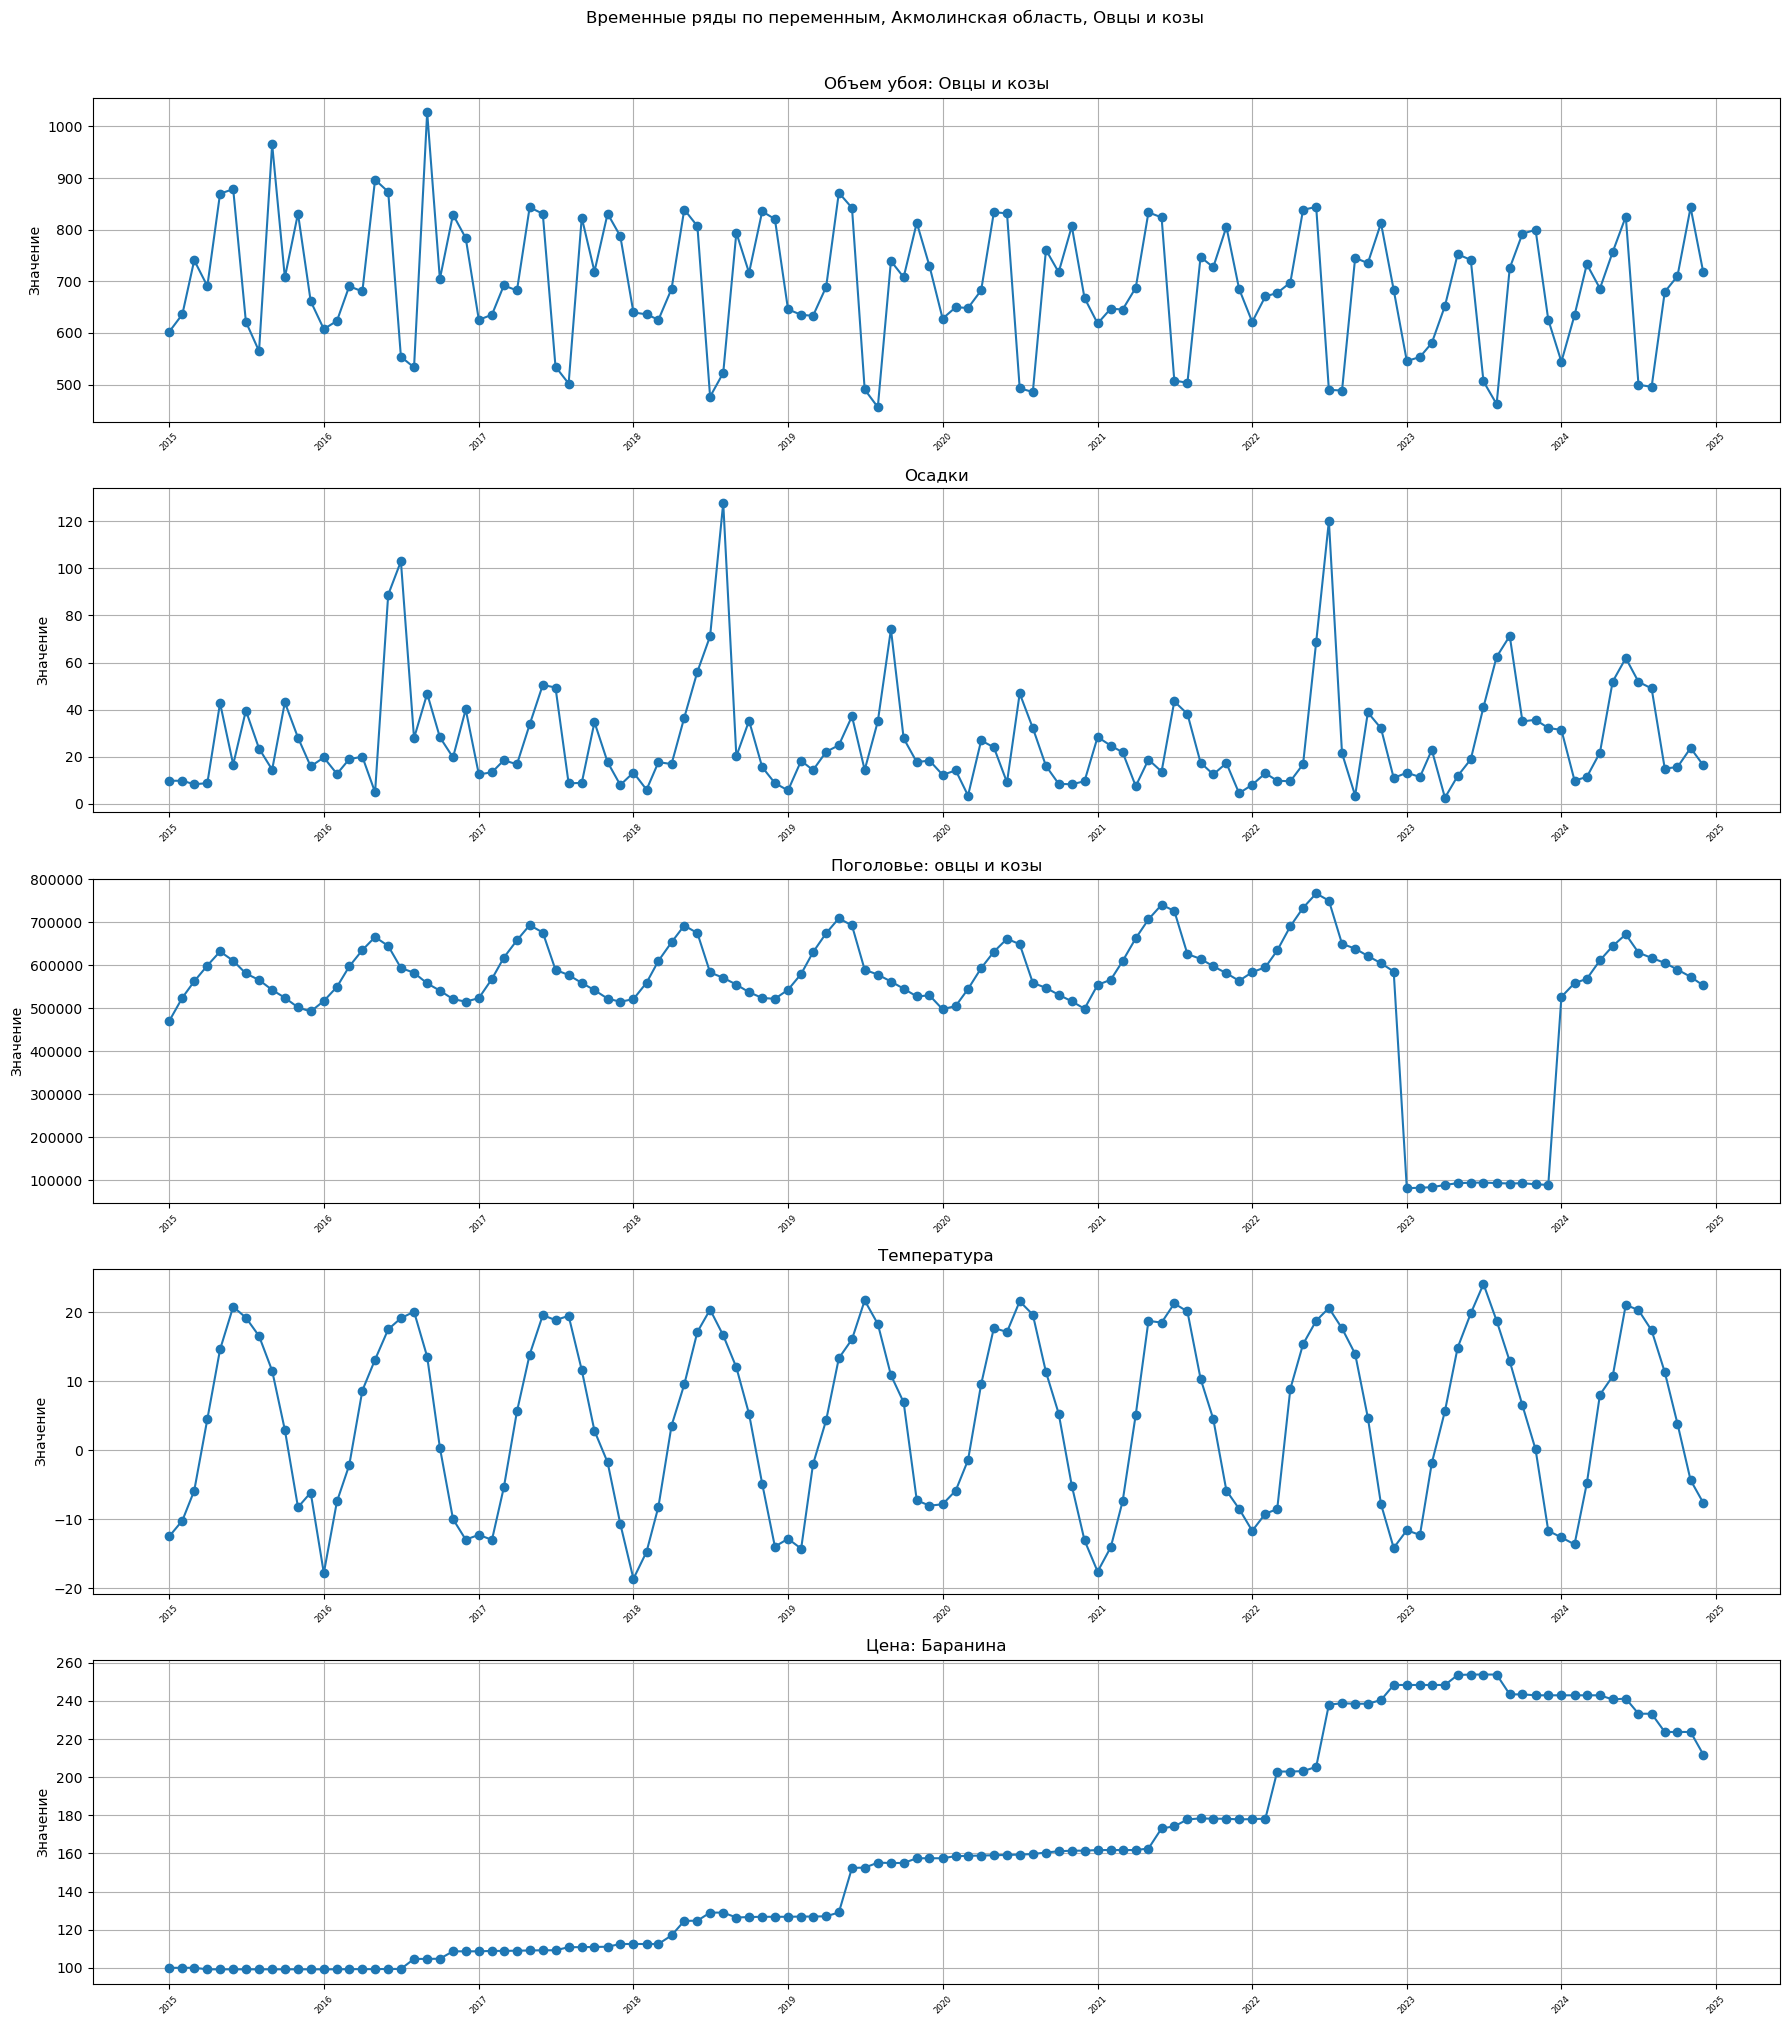

In [7]:
# Plot each variable in its own subplot
value_cols = [col for col in df_akmola.columns if col not in ["Период"]]

n = len(value_cols)
plt.figure(figsize=(18, 4 * n))

for i, col in enumerate(value_cols, 1):
    plt.subplot(n, 1, i)
    plt.plot(df_akmola["Период"], df_akmola[col], marker="o")
    plt.title(f"{col}")
    plt.grid(True)
    plt.ylabel("Значение")
    plt.xticks(rotation=45, fontsize = 6)

plt.suptitle("Временные ряды по переменным, Акмолинская область, Овцы и козы", y=1.01)
plt.tight_layout()
plt.show()

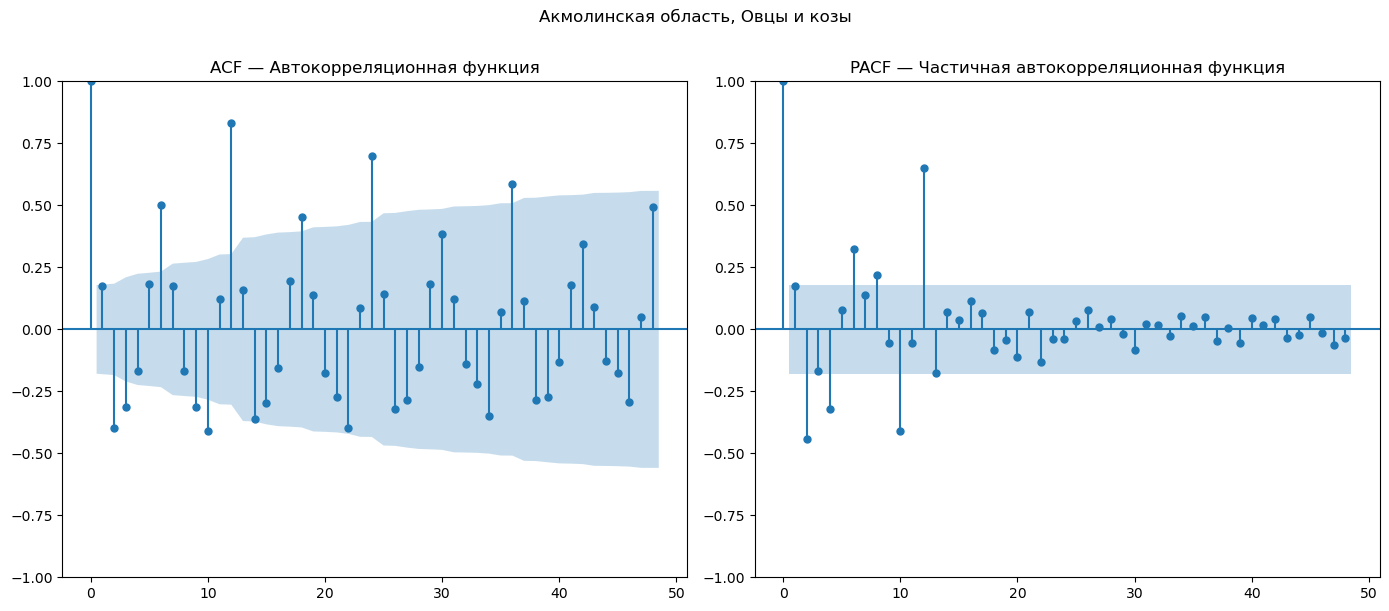

In [9]:
y = df_akmola["Объем убоя: Овцы и козы"].sort_index()

# Plot ACF and PACF
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plot_acf(y, lags=48, ax=plt.gca(), title="ACF — Автокорреляционная функция")

plt.subplot(1, 2, 2)
plot_pacf(y, lags=48, ax=plt.gca(), title="PACF — Частичная автокорреляционная функция", method="ywm")
plt.suptitle("Акмолинская область, Овцы и козы", y=1.01)

plt.tight_layout()
plt.show()

Графики автокорреляционной и частичной автокорреляционной функций указывают на возможную **годовую сезонность** (пики на +12, +24, +36 и +48 месяцев). 

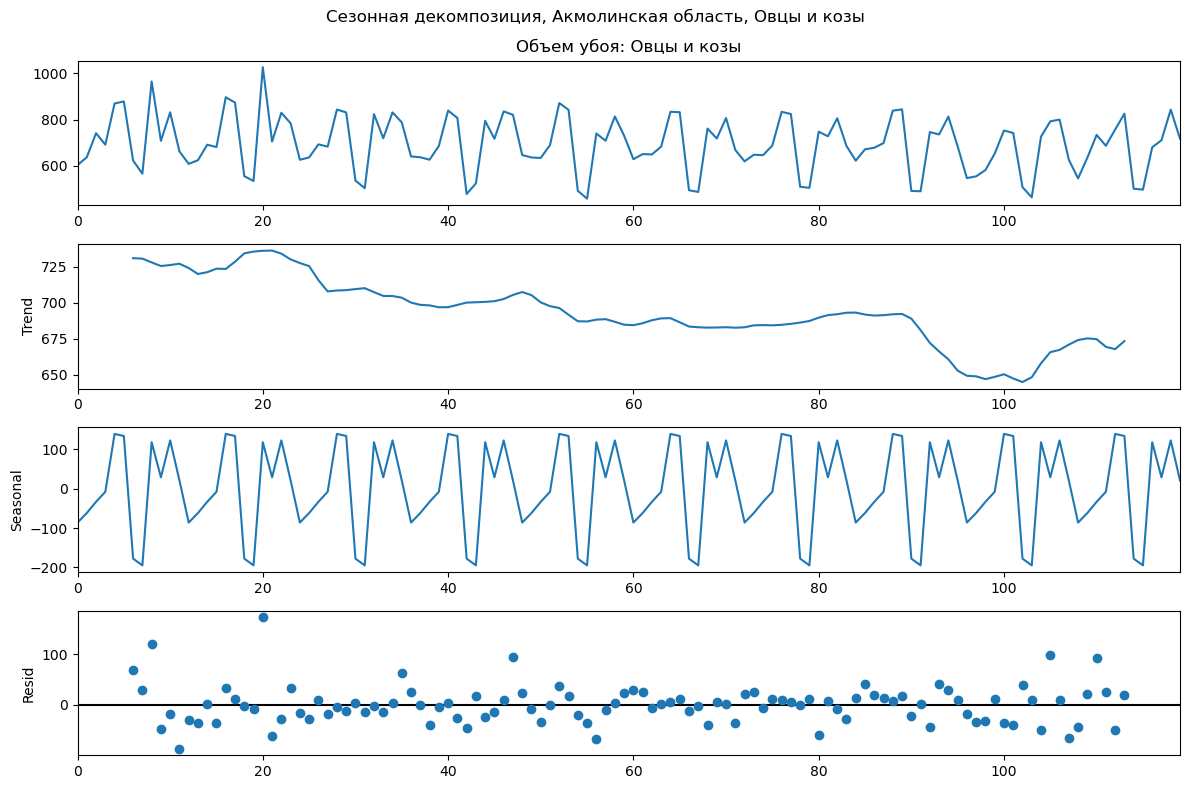

In [10]:
# Perform decomposition (period=12 for monthly data)
decomposition = seasonal_decompose(df_akmola["Объем убоя: Овцы и козы"], model="additive", period=12)

# Plot with larger figure size
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Сезонная декомпозиция, Акмолинская область, Овцы и козы", fontsize=12)
plt.tight_layout()
plt.show()


In [11]:
# Run ADF test
result = adfuller(df_akmola["Объем убоя: Овцы и козы"])

# Display results
print("📊 Augmented Dickey-Fuller Test Results:")
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
for key, value in result[4].items():
    print(f"Critical Value ({key}): {value:.4f}")

# Interpretation
if result[1] < 0.05:
    print("✅ The series is likely **stationary** (reject H₀).")
else:
    print("❌ The series is likely **non-stationary** (fail to reject H₀).")


📊 Augmented Dickey-Fuller Test Results:
ADF Statistic: -1.2392
p-value: 0.6565
Critical Value (1%): -3.4936
Critical Value (5%): -2.8892
Critical Value (10%): -2.5815
❌ The series is likely **non-stationary** (fail to reject H₀).


Результаты теста ADF указывают на **нестационарность** временного ряда.

In [12]:
df_akmola

,Период,Объем убоя: Овцы и козы,Осадки,Поголовье: овцы и козы,Температура,Цена: Баранина
0,2015-01-01,602.28,9.8,470582,-12.490323,100.000000
1,2015-02-01,636.18,9.8,524810,-10.192857,100.000000
2,2015-03-01,740.73,8.3,562860,-5.870968,100.000000
3,2015-04-01,690.81,8.8,599518,4.490000,99.200000
4,2015-05-01,869.73,42.8,632220,14.574194,99.200000
...,...,...,...,...,...,...
115,2024-08-01,495.67,49.0,617265,17.338710,233.308116
116,2024-09-01,679.44,15.0,605725,11.300000,223.742483
117,2024-10-01,710.13,15.6,590131,3.832258,223.742483
118,2024-11-01,843.07,23.7,573342,-4.343333,223.742483


In [13]:
# Создание лагов t-1 до t-6 для переменных
for lag in range(1, 7):
    df_akmola[f"Овцы и козы_t-{lag}"] = df_akmola["Объем убоя: Овцы и козы"].shift(lag)
    df_akmola[f"Температура_t-{lag}"] = df_akmola["Температура"].shift(lag)
    df_akmola[f"Осадки_t-{lag}"] = df_akmola["Осадки"].shift(lag)
    df_akmola[f"Поголовье: овцы и козы_t-{lag}"] = df_akmola["Поголовье: овцы и козы"].shift(lag)
    df_akmola[f"Цена: Баранина_t-{lag}"] = df_akmola["Цена: Баранина"].shift(lag)

df_akmola_full = df_akmola[["Период", "Объем убоя: Овцы и козы", 
                            "Овцы и козы_t-1", "Овцы и козы_t-2", "Овцы и козы_t-3", "Овцы и козы_t-4", "Овцы и козы_t-5", "Овцы и козы_t-6",
                            "Температура", "Температура_t-1", "Температура_t-2", "Температура_t-3", "Температура_t-4", "Температура_t-5", "Температура_t-6",
                            "Осадки", "Осадки_t-1", "Осадки_t-2", "Осадки_t-3", "Осадки_t-4", "Осадки_t-5", "Осадки_t-6",
                            "Поголовье: овцы и козы", "Поголовье: овцы и козы_t-1", "Поголовье: овцы и козы_t-2", "Поголовье: овцы и козы_t-3", "Поголовье: овцы и козы_t-4", "Поголовье: овцы и козы_t-5", "Поголовье: овцы и козы_t-6",
                            "Цена: Баранина", "Цена: Баранина_t-1", "Цена: Баранина_t-2", "Цена: Баранина_t-3", "Цена: Баранина_t-4", "Цена: Баранина_t-5", "Цена: Баранина_t-6"]]
df_akmola_full

,Период,Объем убоя: Овцы и козы,Овцы и козы_t-1,Овцы и козы_t-2,Овцы и козы_t-3,Овцы и козы_t-4,Овцы и козы_t-5,Овцы и козы_t-6,Температура,Температура_t-1,Температура_t-2,Температура_t-3,Температура_t-4,Температура_t-5,Температура_t-6,Осадки,Осадки_t-1,Осадки_t-2,Осадки_t-3,Осадки_t-4,Осадки_t-5,Осадки_t-6,Поголовье: овцы и козы,Поголовье: овцы и козы_t-1,Поголовье: овцы и козы_t-2,Поголовье: овцы и козы_t-3,Поголовье: овцы и козы_t-4,Поголовье: овцы и козы_t-5,Поголовье: овцы и козы_t-6,Цена: Баранина,Цена: Баранина_t-1,Цена: Баранина_t-2,Цена: Баранина_t-3,Цена: Баранина_t-4,Цена: Баранина_t-5,Цена: Баранина_t-6
0,2015-01-01,602.28,NaN,NaN,NaN,NaN,NaN,NaN,-12.490323,NaN,NaN,NaN,NaN,NaN,NaN,9.8,NaN,NaN,NaN,NaN,NaN,NaN,470582,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-02-01,636.18,602.28,NaN,NaN,NaN,NaN,NaN,-10.192857,-12.490323,NaN,NaN,NaN,NaN,NaN,9.8,9.8,NaN,NaN,NaN,NaN,NaN,524810,470582.0,NaN,NaN,NaN,NaN,NaN,100.000000,100.000000,NaN,NaN,NaN,NaN,NaN
2,2015-03-01,740.73,636.18,602.28,NaN,NaN,NaN,NaN,-5.870968,-10.192857,-12.490323,NaN,NaN,NaN,NaN,8.3,9.8,9.8,NaN,NaN,NaN,NaN,562860,524810.0,470582.0,NaN,NaN,NaN,NaN,100.000000,100.000000,100.000000,NaN,NaN,NaN,NaN
3,2015-04-01,690.81,740.73,636.18,602.28,NaN,NaN,NaN,4.490000,-5.870968,-10.192857,-12.490323,NaN,NaN,NaN,8.8,8.3,9.8,9.8,NaN,NaN,NaN,599518,562860.0,524810.0,470582.0,NaN,NaN,NaN,99.200000,100.000000,100.000000,100.000000,NaN,NaN,NaN
4,2015-05-01,869.73,690.81,740.73,636.18,602.28,NaN,NaN,14.574194,4.490000,-5.870968,-10.192857,-12.490323,NaN,NaN,42.8,8.8,8.3,9.8,9.8,NaN,NaN,632220,599518.0,562860.0,524810.0,470582.0,NaN,NaN,99.200000,99.200000,100.000000,100.000000,100.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2024-08-01,495.67,499.73,825.36,756.58,686.11,733.22,634.45,17.338710,20.270968,21.043333,10.696774,8.026667,-4.809677,-13.644828,49.0,51.8,61.9,51.9,21.8,11.4,9.9,617265,629464.0,672157.0,644743.0,611627.0,568572.0,558776.0,233.308116,233.308116,241.270027,240.788450,242.975227,242.975227,242.975227
116,2024-09-01,679.44,495.67,499.73,825.36,756.58,686.11,733.22,11.300000,17.338710,20.270968,21.043333,10.696774,8.026667,-4.809677,15.0,49.0,51.8,61.9,51.9,21.8,11.4,605725,617265.0,629464.0,672157.0,644743.0,611627.0,568572.0,223.742483,233.308116,233.308116,241.270027,240.788450,242.975227,242.975227
117,2024-10-01,710.13,679.44,495.67,499.73,825.36,756.58,686.11,3.832258,11.300000,17.338710,20.270968,21.043333,10.696774,8.026667,15.6,15.0,49.0,51.8,61.9,51.9,21.8,590131,605725.0,617265.0,629464.0,672157.0,644743.0,611627.0,223.742483,223.742483,233.308116,233.308116,241.270027,240.788450,242.975227
118,2024-11-01,843.07,710.13,679.44,495.67,499.73,825.36,756.58,-4.343333,3.832258,11.300000,17.338710,20.270968,21.043333,10.696774,23.7,15.6,15.0,49.0,51.8,61.9,51.9,573342,590131.0,605725.0,617265.0,629464.0,672157.0,644743.0,223.742483,223.742483,223.742483,233.308116,233.308116,241.270027,240.788450


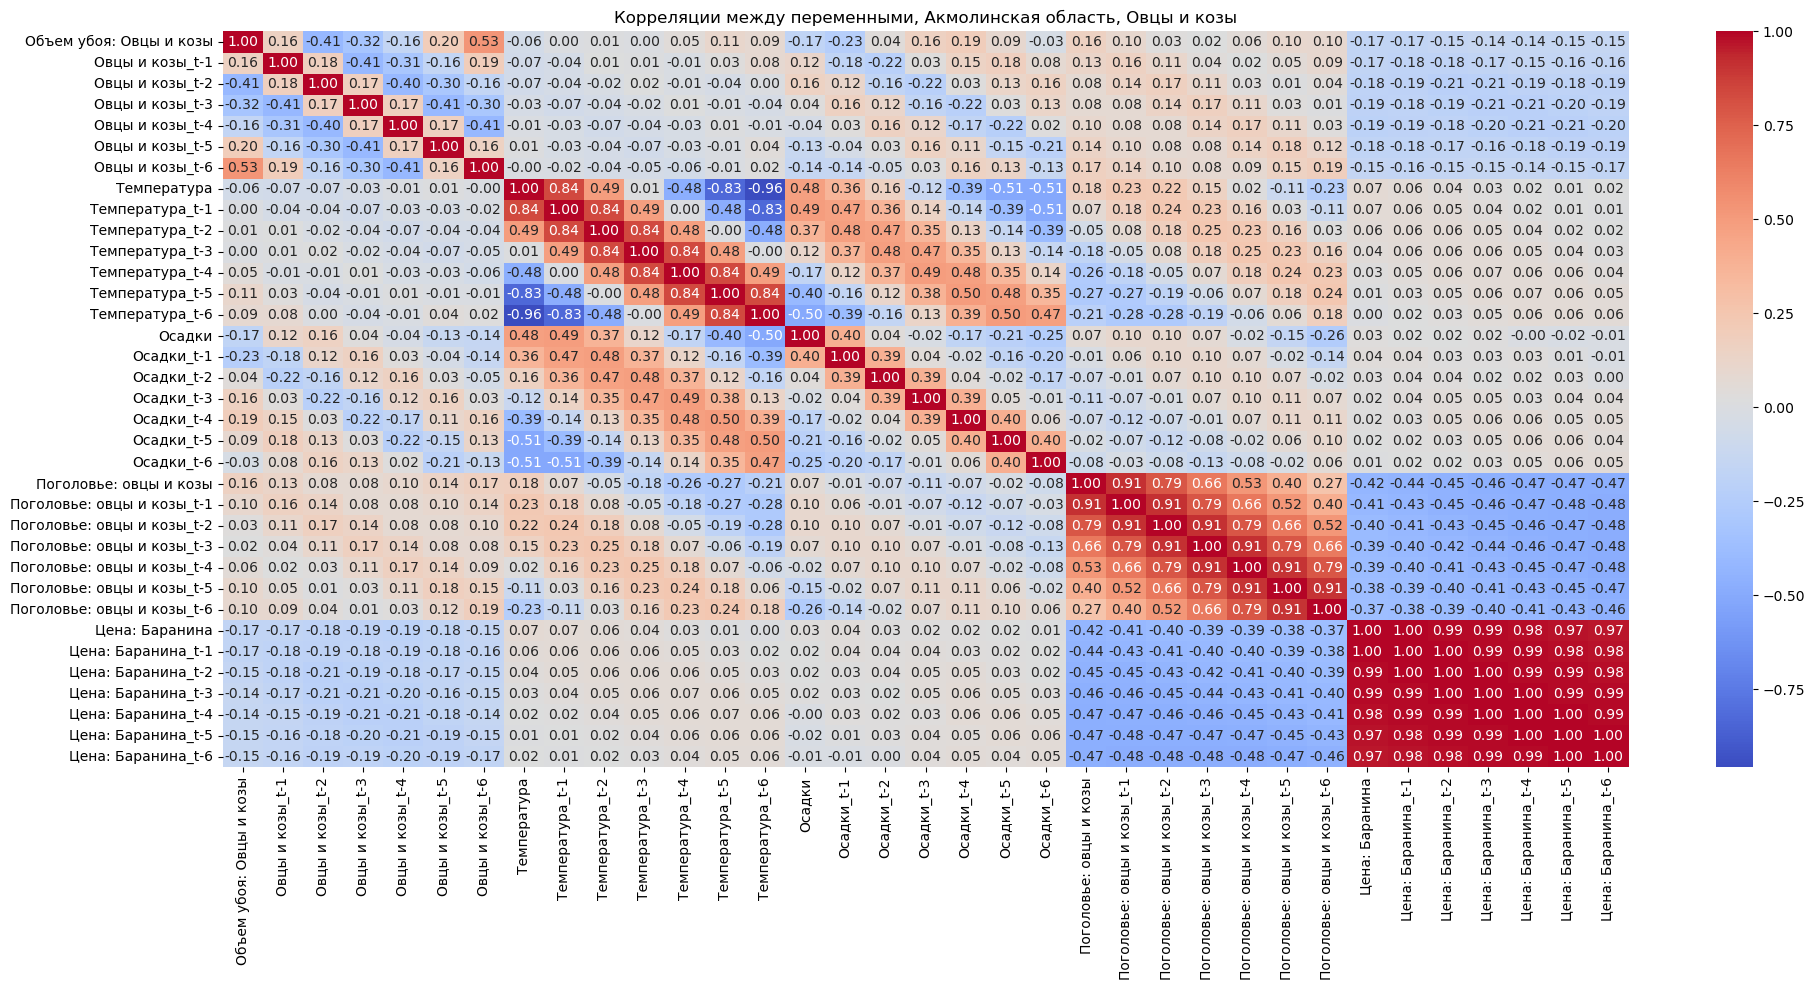

In [14]:
df_corr = df_akmola_full[[col for col in df_akmola_full.columns if col not in ["Период"]]].dropna().copy()

# 1. Correlation matrix
corr_matrix = df_corr.corr()

# 2. Plot heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляции между переменными, Акмолинская область, Овцы и козы")
plt.tight_layout()
plt.show()

*ВЫВОДЫ ПО КОРРЕЛЯЦИИ*

In [15]:
# Set your target variable
target_var = "Объем убоя: Овцы и козы"

# Get correlations with the target variable
target_corr = corr_matrix[target_var].drop(target_var)  # exclude self-correlation

# Keep only features with |correlation| >= 0.5
selected_vars = target_corr[abs(target_corr) >= 0.5].index.tolist()

print("✅ Отобранные переменные с корреляцией >= 0.5:")
print(selected_vars)

# Optionally: create new dataframe with selected variables + target
df_selected = df_akmola_full[['Период'] + selected_vars + [target_var]]
df_selected

✅ Отобранные переменные с корреляцией >= 0.5:
['Овцы и козы_t-6']


,Период,Овцы и козы_t-6,Объем убоя: Овцы и козы
0,2015-01-01,NaN,602.28
1,2015-02-01,NaN,636.18
2,2015-03-01,NaN,740.73
3,2015-04-01,NaN,690.81
4,2015-05-01,NaN,869.73
...,...,...,...
115,2024-08-01,634.45,495.67
116,2024-09-01,733.22,679.44
117,2024-10-01,686.11,710.13
118,2024-11-01,756.58,843.07


In [16]:
df_vif = df_selected[[col for col in df_selected.columns if col not in ["Период"]]].dropna().copy()

X_vif = add_constant(df_vif[[i for i in df_vif.columns if i != "Объем убоя: Овцы и козы"]])

vif_data = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data.sort_values('VIF')

,Variable,VIF
1,Овцы и козы_t-6,1.000000
0,const,34.987634


Step-by-Step Strategy to Handle High VIFs:

Sort VIFs in descending order
Drop variables one at a time, starting with the one that has the highest VIF.

Check domain relevance
Keep variables that are theoretically important or core to your hypothesis, even if VIF is high.

Evaluate correlation matrix
If two variables have high correlation with each other, and both have high VIFs, drop the one less correlated with the target.

Recalculate VIF after each drop
After dropping one variable, recalculate all VIFs. Sometimes removing just one variable significantly reduces others.

Use stepwise selection (optional)
Automated methods like backward elimination can help drop redundant predictors based on model fit and VIF thresholds.

In [ ]:
# df_selected = df_selected.drop(columns = ['Температура', 'Температура_t-2', 'Температура_t-3', 'Температура_t-6'])
# df_selected

In [ ]:
# df_vif = df_selected[[col for col in df_selected.columns if col not in ["Период"]]].dropna().copy()
# X_vif = add_constant(df_vif[[i for i in df_vif.columns if i != "Объем убоя: Овцы и козы"]])

# vif_data = pd.DataFrame({
#     "Variable": X_vif.columns,
#     "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
# })
# vif_data.sort_values('VIF')

In [17]:
df_selected = df_selected.dropna().copy()
df_selected

,Период,Овцы и козы_t-6,Объем убоя: Овцы и козы
6,2015-07-01,602.28,621.61
7,2015-08-01,636.18,564.95
8,2015-09-01,740.73,965.19
9,2015-10-01,690.81,707.45
10,2015-11-01,869.73,831.21
...,...,...,...
115,2024-08-01,634.45,495.67
116,2024-09-01,733.22,679.44
117,2024-10-01,686.11,710.13
118,2024-11-01,756.58,843.07


### Models

#### Многофакторная регрессия

In [18]:
# Define target and features
y = df_selected["Объем убоя: Овцы и козы"]
X = df_selected.drop(columns=["Период", "Объем убоя: Овцы и козы"])

# Add constant term
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Show summary
print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     Объем убоя: Овцы и козы   R-squared:                       0.279
Model:                                 OLS   Adj. R-squared:                  0.272
Method:                      Least Squares   F-statistic:                     43.31
Date:                     Tue, 19 Aug 2025   Prob (F-statistic):           1.56e-09
Time:                             15:44:10   Log-Likelihood:                -689.14
No. Observations:                      114   AIC:                             1382.
Df Residuals:                          112   BIC:                             1388.
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

In [19]:
df_selected

,Период,Овцы и козы_t-6,Объем убоя: Овцы и козы
6,2015-07-01,602.28,621.61
7,2015-08-01,636.18,564.95
8,2015-09-01,740.73,965.19
9,2015-10-01,690.81,707.45
10,2015-11-01,869.73,831.21
...,...,...,...
115,2024-08-01,634.45,495.67
116,2024-09-01,733.22,679.44
117,2024-10-01,686.11,710.13
118,2024-11-01,756.58,843.07


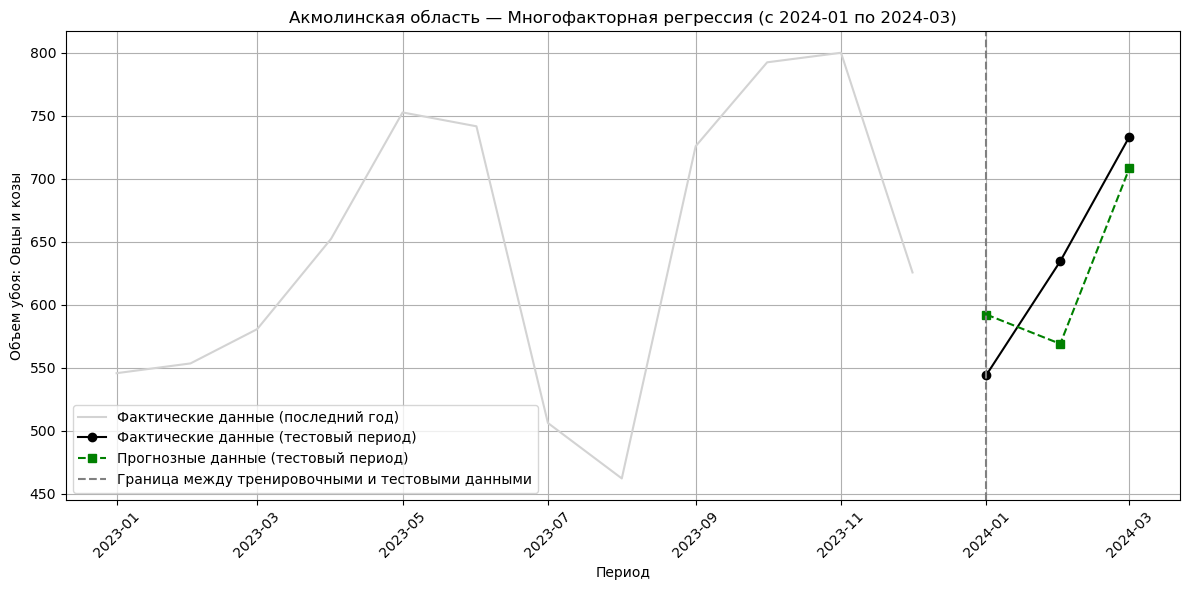

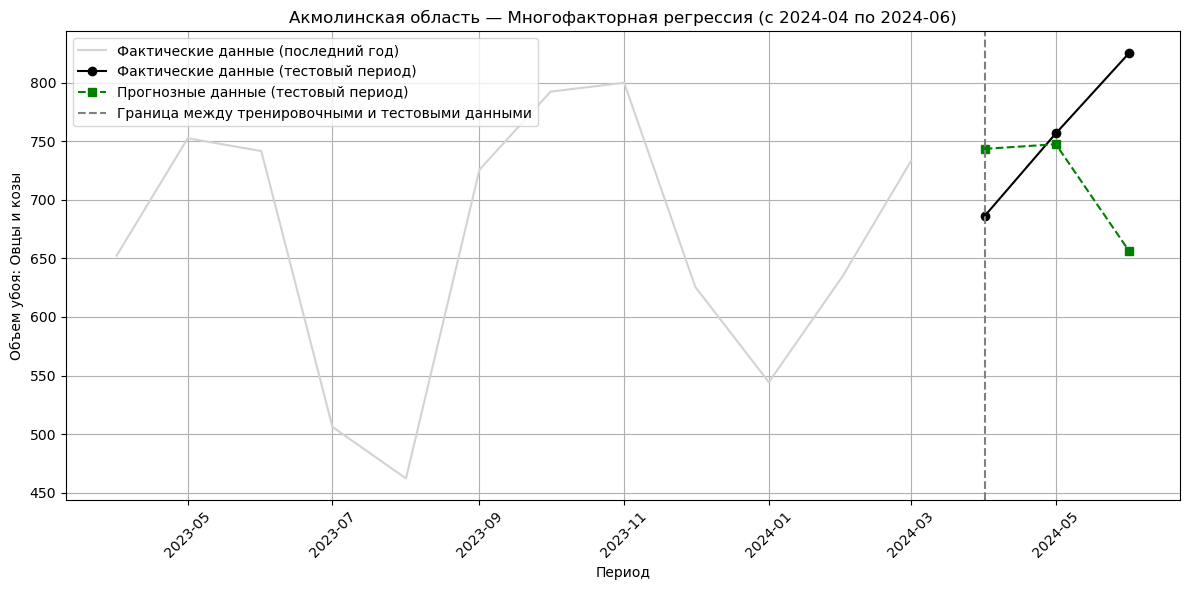

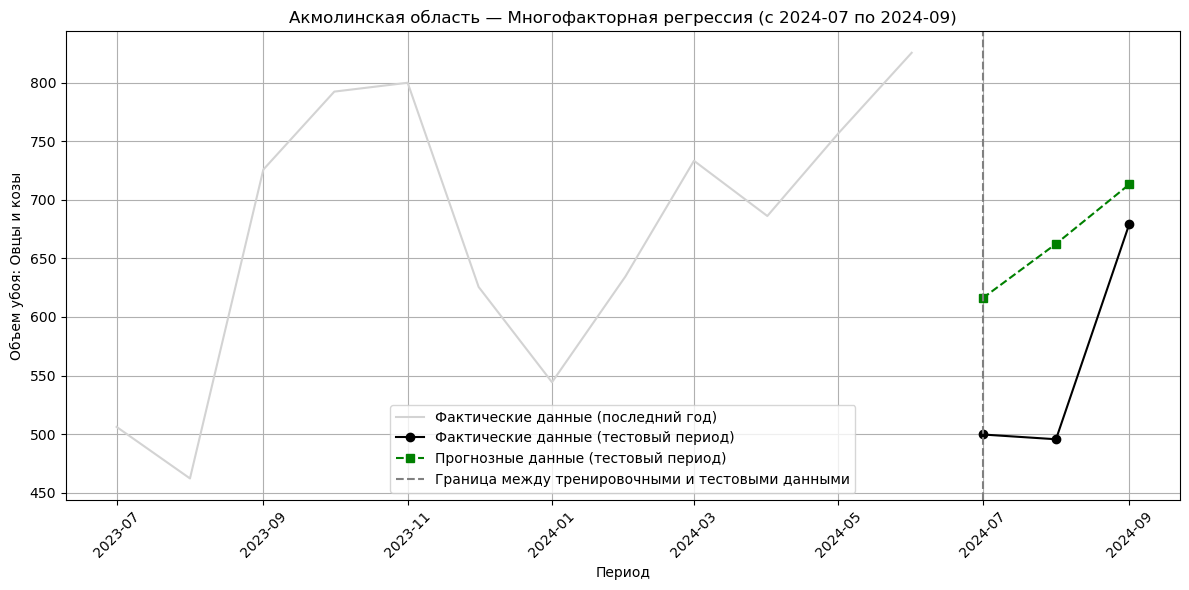

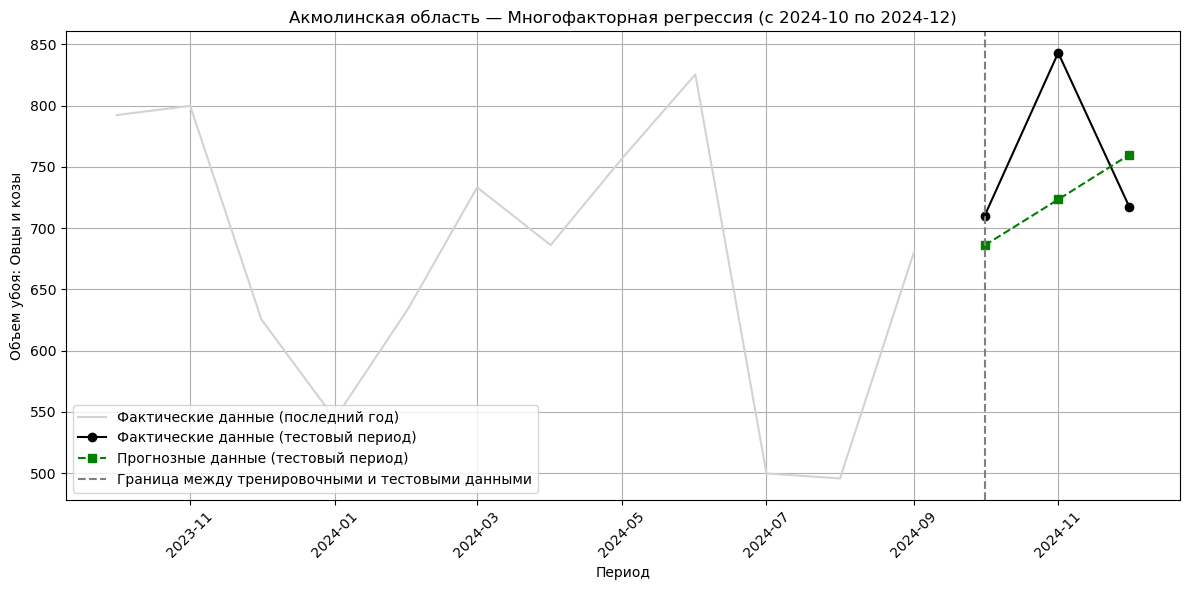

In [20]:
df = df_selected.sort_values("Период").copy()

target = "Объем убоя: Овцы и козы"
features = [col for col in df_selected.columns if col not in ['Период', 'Объем убоя: Овцы и козы']]

results = []

# Define 4 rolling test sets for 2024
start_dates = ["2024-01", "2024-04", "2024-07", "2024-10"]

for start in start_dates:
    test_start = pd.to_datetime(start)
    test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)

    # Split data
    train_df = df[df["Период"] < test_start]
    test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

    X_train = sm.add_constant(train_df[features])
    y_train = train_df[target]

    X_test = sm.add_constant(test_df[features])
    y_test = test_df[target]

    # Fit and predict
    model = sm.OLS(y_train, X_train).fit()
    y_pred = model.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = (np.abs((y_test - y_pred) / y_test).mean()) * 100
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Test period": f"{start} to {test_end.strftime('%Y-%m')}",
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        # "R²": r2
    })
    plt.figure(figsize=(12, 6))
    last_train_year = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
    plt.plot(last_train_year["Период"], last_train_year[target], color="lightgray", label="Фактические данные (последний год)")

    plt.plot(test_df["Период"], y_test.values, marker="o", color="black", label="Фактические данные (тестовый период)")
    plt.plot(test_df["Период"], y_pred.values, marker="s", linestyle="--", color="green", label="Прогнозные данные (тестовый период)")

    plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
    plt.title(f"Акмолинская область — Многофакторная регрессия (с {start} по {test_end.strftime('%Y-%m')})")
    plt.xlabel("Период")
    plt.ylabel("Объем убоя: Овцы и козы")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [21]:
# Convert to DataFrame
results_df = pd.DataFrame(results)
avg_row = results_df.mean(numeric_only=True).to_dict()
avg_row["Test period"] = "Average"
results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# Show results
print(results_df)

          Test period        RMSE         MAE   MAPE (%)
0  2024-01 to 2024-03   49.012185   46.132207   7.510367
1  2024-04 to 2024-06  103.400903   78.646925  10.032154
2  2024-07 to 2024-09  118.935142  105.553504  20.618358
3  2024-10 to 2024-12   74.702708   62.192075   7.851814
4             Average   86.512735   73.131178  11.503173


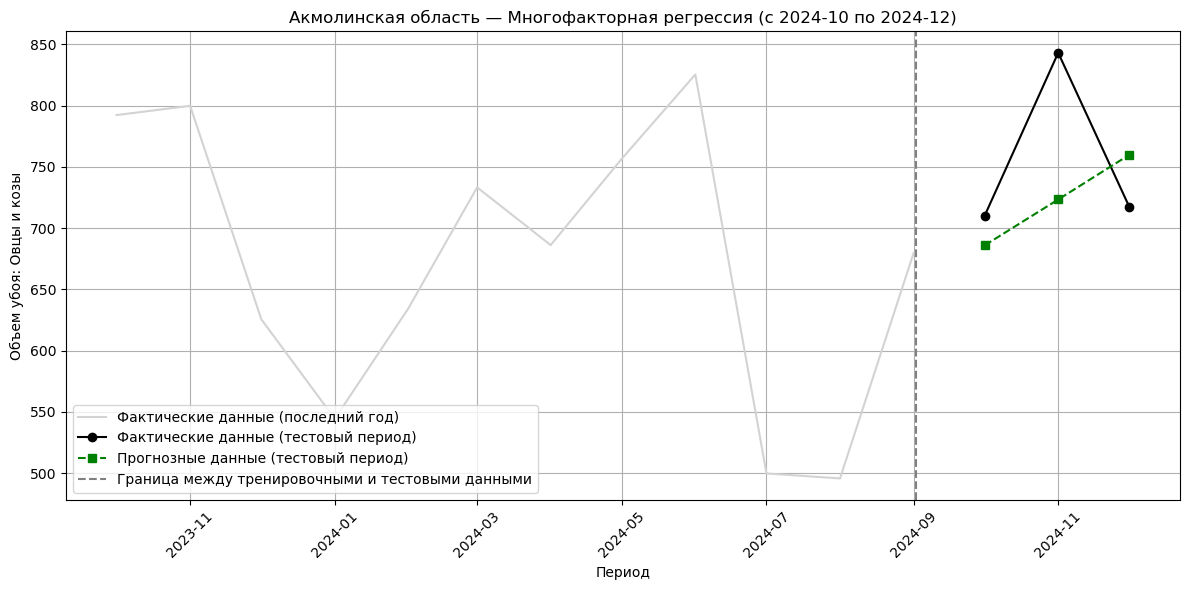

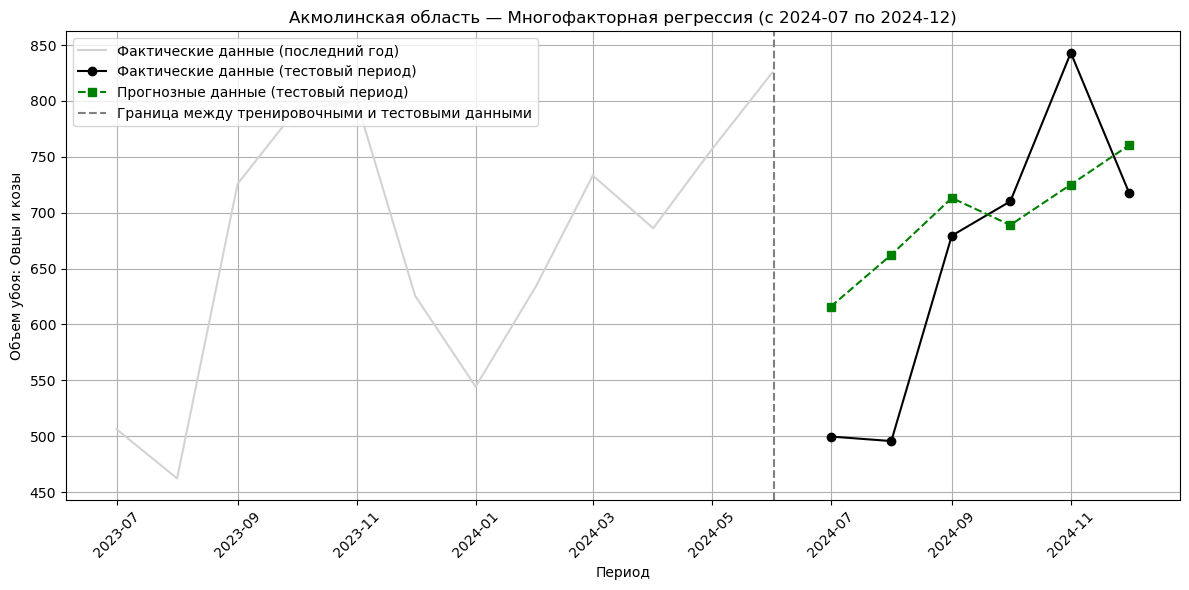

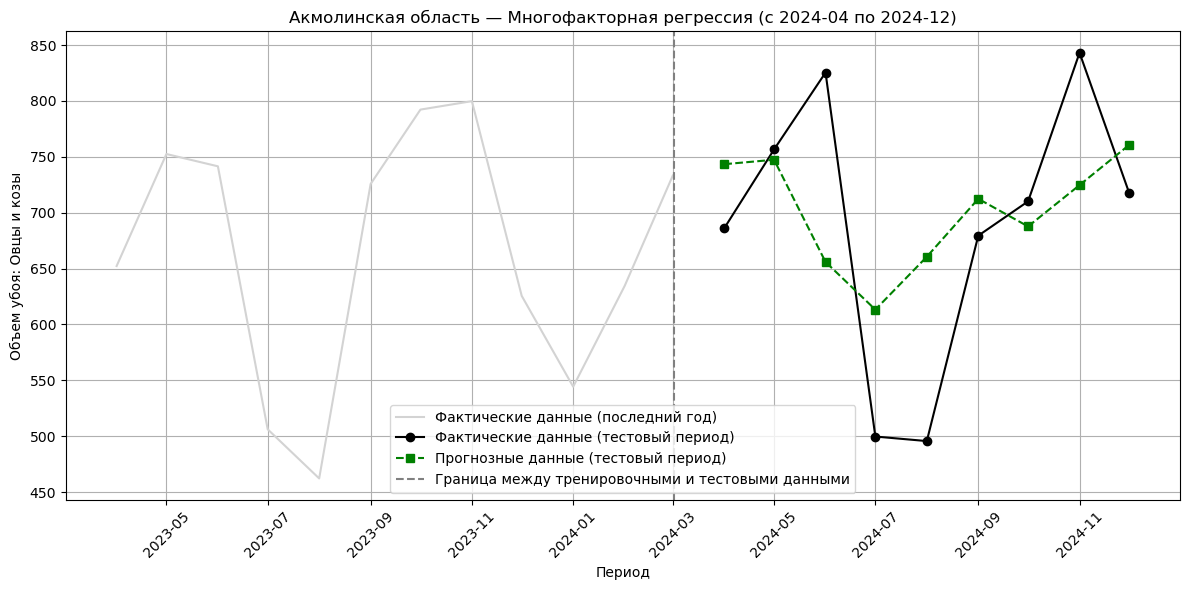

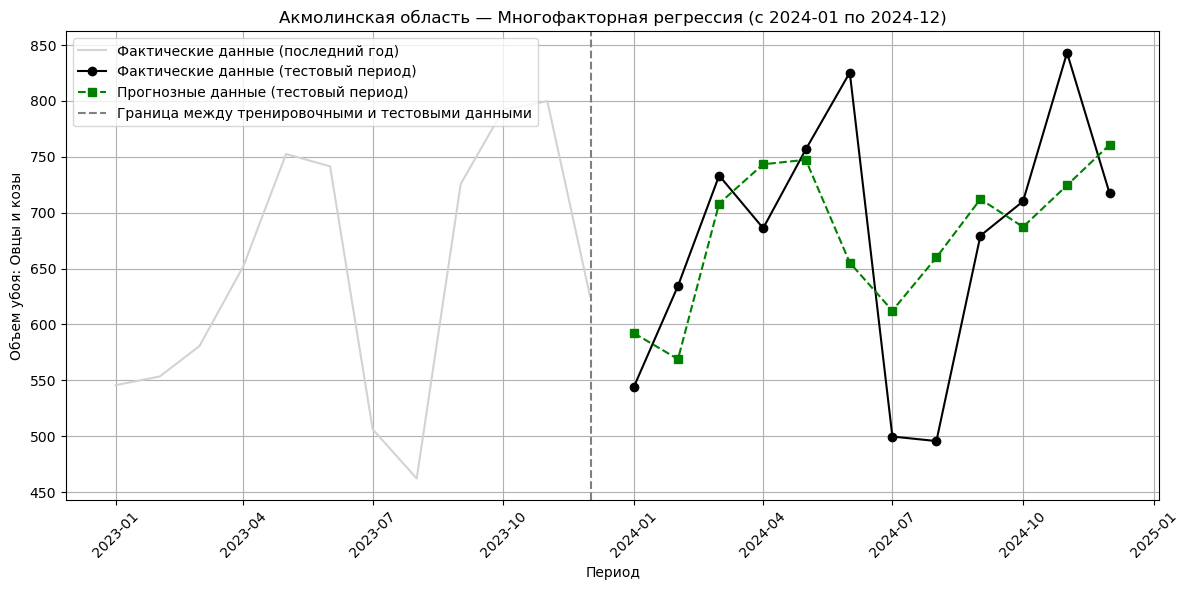

In [22]:
results = []

# Define 4 rolling test sets for 2024
horizons = [3, 6, 9, 12]

for horizon in horizons:

    test_end = pd.to_datetime("2024-12")
    test_start = test_end - pd.DateOffset(months=horizon) + pd.DateOffset(days=1)

    # Split data
    train_df = df[df["Период"] < test_start]
    test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

    X_train = sm.add_constant(train_df[features])
    y_train = train_df[target]

    X_test = sm.add_constant(test_df[features])
    y_test = test_df[target]

    # Fit and predict
    model = sm.OLS(y_train, X_train).fit()
    y_pred = model.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = (np.abs((y_test - y_pred) / y_test).mean()) * 100
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Test period": f"{(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} to {test_end.strftime('%Y-%m')}",
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        # "R²": r2
    })
    plt.figure(figsize=(12, 6))
    last_train_year = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
    plt.plot(last_train_year["Период"], last_train_year[target], color="lightgray", label="Фактические данные (последний год)")

    plt.plot(test_df["Период"], y_test.values, marker="o", color="black", label="Фактические данные (тестовый период)")
    plt.plot(test_df["Период"], y_pred.values, marker="s", linestyle="--", color="green", label="Прогнозные данные (тестовый период)")

    plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
    plt.title(f"Акмолинская область — Многофакторная регрессия (с {(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
    plt.xlabel("Период")
    plt.ylabel("Объем убоя: Овцы и козы")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [23]:
# Convert to DataFrame
results_df = pd.DataFrame(results)
avg_row = results_df.mean(numeric_only=True).to_dict()
avg_row["Test period"] = "Average"
results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# Show results
print(results_df)

          Test period       RMSE        MAE   MAPE (%)
0  2024-10 to 2024-12  74.702708  62.192075   7.851814
1  2024-07 to 2024-12  98.882002  83.186015  14.145030
2  2024-04 to 2024-12  99.816115  81.308852  12.691107
3  2024-01 to 2024-12  89.780334  72.470998  11.380379
4             Average  90.795290  74.789485  11.517083


#### SARIMA (auto-arima)

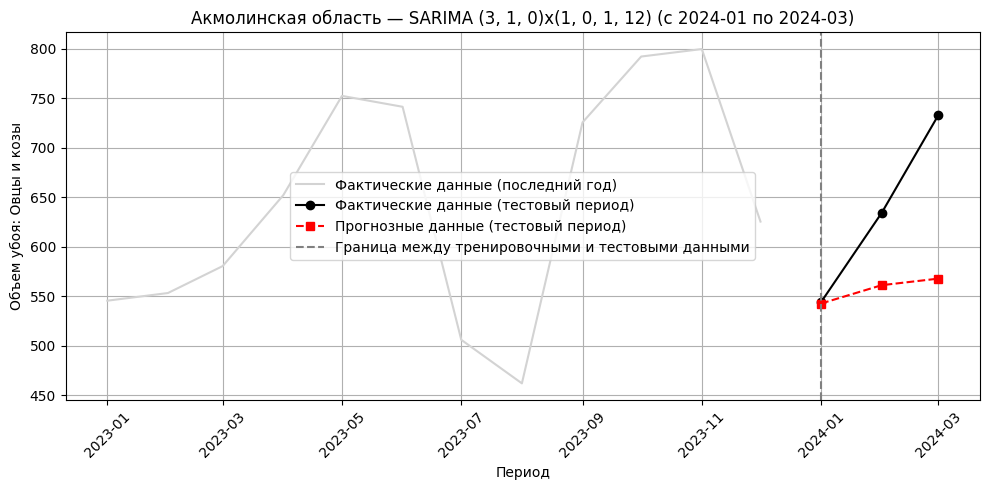

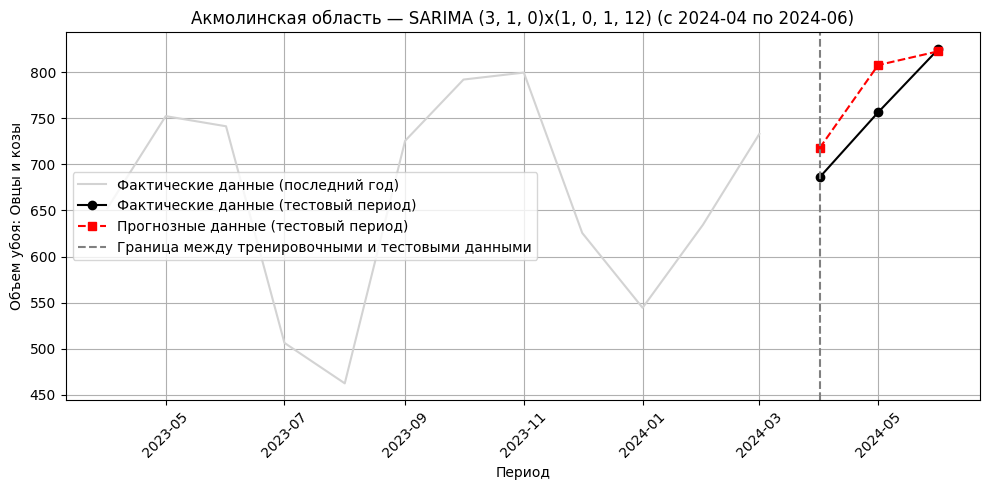

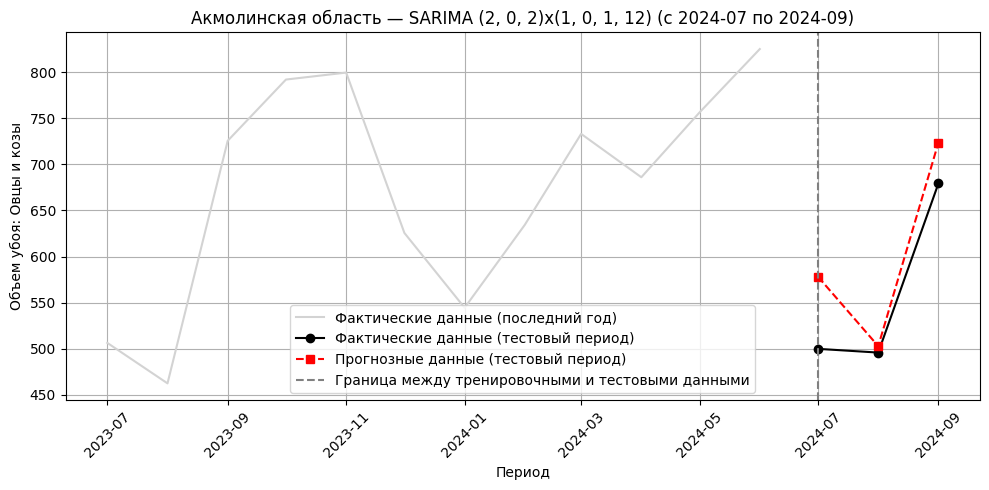

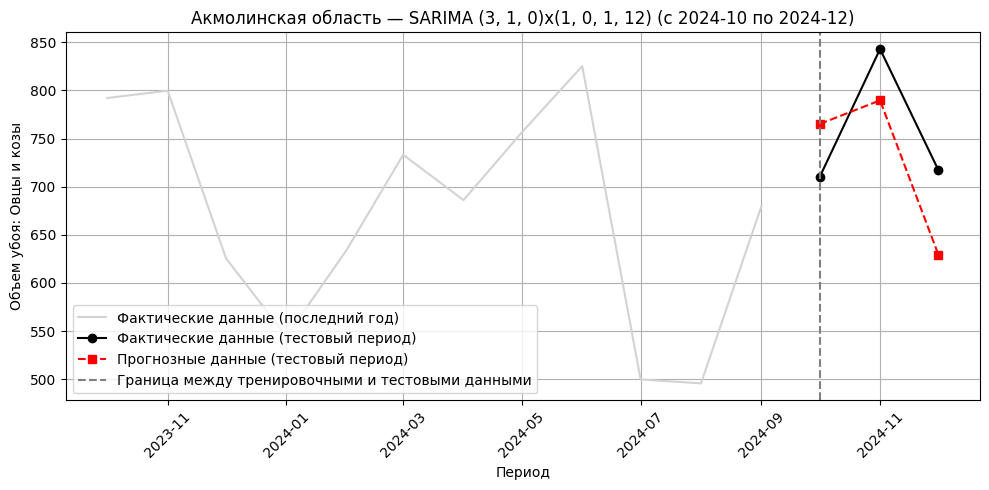

In [ ]:
# results = []

# # Определим 4 тестовых периода на 3 месяца
# start_dates = ["2024-01", "2024-04", "2024-07", "2024-10"]

# for start in start_dates:
#     test_start = pd.to_datetime(start)
#     test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)

#     # Разделим данные
#     train_df = df[df["Период"] < test_start]
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

#     y_train = train_df[target].reset_index(drop=True)
#     y_test = test_df[target].reset_index(drop=True)

#     try:
#         model = auto_arima(
#             y_train,
#             seasonal=True,
#             m=12,
#             stepwise=True,
#             suppress_warnings=True,
#             error_action="ignore"
#         )

#         forecast = model.predict(n_periods=3)
#         forecast = pd.Series(forecast).reset_index(drop=True)


#         # Оценка
#         rmse = np.sqrt(mean_squared_error(y_test, forecast))
#         mae = mean_absolute_error(y_test, forecast)
#         mape = (np.abs((y_test - forecast) / y_test).mean()) * 100

#         results.append({
#             "Test period": f"{start} to {test_end.strftime('%Y-%m')}",
#             "RMSE": rmse,
#             "MAE": mae,
#             "MAPE (%)": mape,
#             "SARIMA order": model.order,
#             "Seasonal order": model.seasonal_order
#         })

#         # График
#         plt.figure(figsize=(10, 5))
#         last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#         plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#         plt.plot(test_df["Период"], y_test, marker="o", color="black", label="Фактические данные (тестовый период)")
#         plt.plot(test_df["Период"], forecast, marker="s", linestyle="--", color="red", label="Прогнозные данные (тестовый период)")
#         plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#         plt.title(f"Акмолинская область — SARIMA {model.order}x{model.seasonal_order} (с {test_start.strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
#         plt.xlabel("Период")
#         plt.ylabel("Объем убоя: Овцы и козы")
#         plt.legend()
#         plt.grid(True)
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()
#         # print("Zero values in y_test:", (y_test == 0).sum())


#     except Exception as e:
#         print(f"⚠️ Ошибка в периоде {start}: {e}")

In [ ]:
# # Вывод метрик
# results_df = pd.DataFrame(results)
# avg_row = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg_row["Test period"] = "Average"
# results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# print(results_df)


          Test period        RMSE        MAE   MAPE (%) SARIMA order  \
0  2024-01 to 2024-03  104.303259  79.922292  11.440692    (3, 1, 0)   
1  2024-04 to 2024-06   34.909924  28.533772   3.906523    (3, 1, 0)   
2  2024-07 to 2024-09   52.119911  43.223915   7.870311    (2, 0, 2)   
3  2024-10 to 2024-12   67.354214  65.443266   8.780301    (3, 1, 0)   
4             Average   64.671827  54.280811   7.999457          NaN   

  Seasonal order  
0  (1, 0, 1, 12)  
1  (1, 0, 1, 12)  
2  (1, 0, 1, 12)  
3  (1, 0, 1, 12)  
4            NaN  


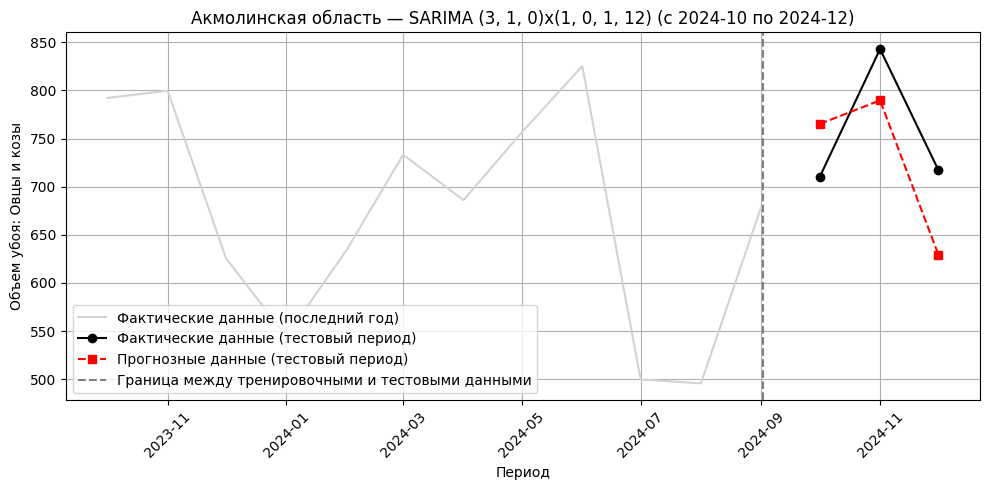

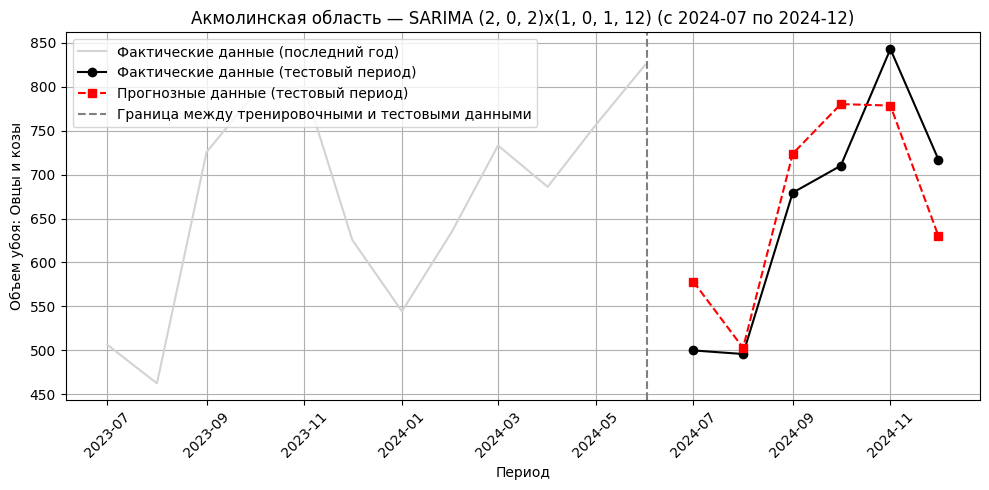

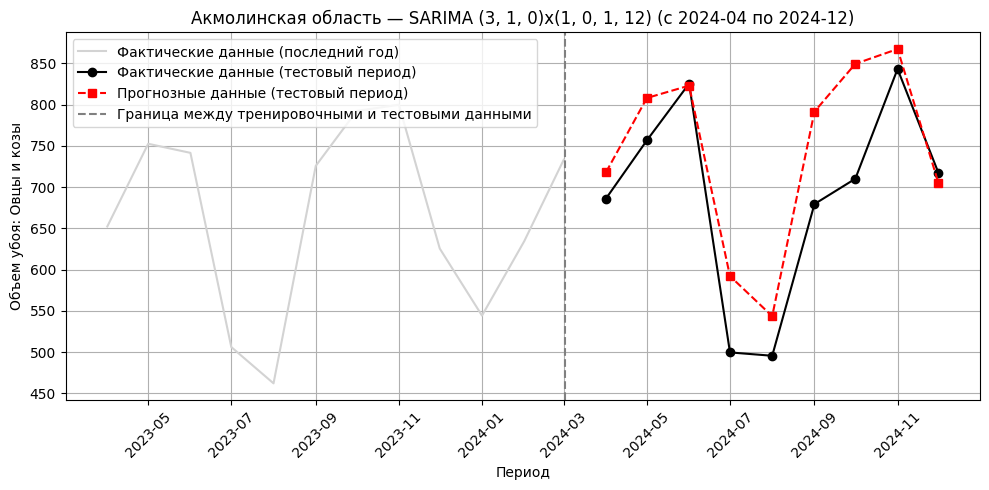

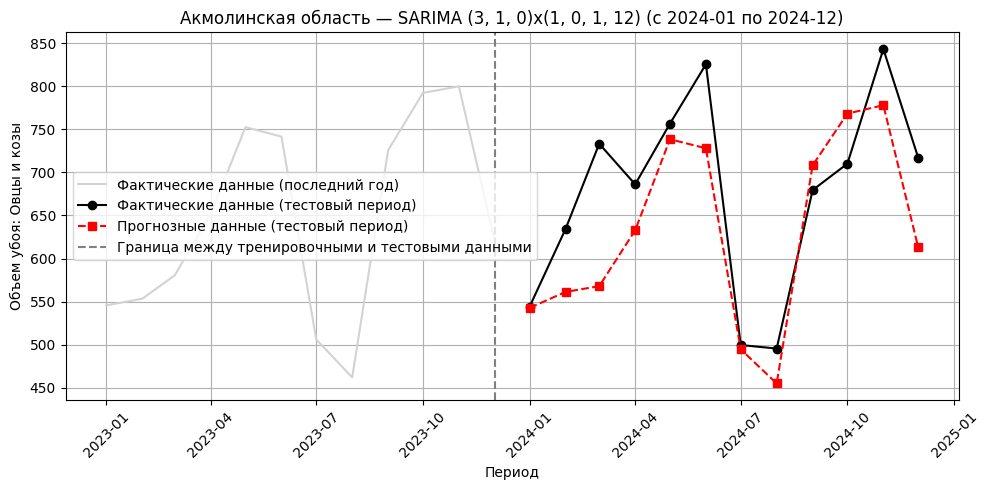

In [ ]:
# results = []

# horizons = [3, 6, 9, 12]

# for horizon in horizons:

#     test_end = pd.to_datetime("2024-12")
#     test_start = test_end - pd.DateOffset(months=horizon) + pd.DateOffset(days=1)
    
#     train_df = df[df["Период"] < test_start]
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

#     y_train = train_df[target].reset_index(drop=True)
#     y_test = test_df[target].reset_index(drop=True)

#     try:
#         model = auto_arima(
#             y_train,
#             seasonal=True,
#             m=12,
#             stepwise=True,
#             suppress_warnings=True,
#             error_action="ignore"
#         )

#         forecast = model.predict(n_periods=horizon)
#         forecast = pd.Series(forecast).reset_index(drop=True)

#         # Оценка
#         rmse = np.sqrt(mean_squared_error(y_test, forecast))
#         mae = mean_absolute_error(y_test, forecast)
#         mape = (np.abs((y_test - forecast) / y_test).mean()) * 100

#         results.append({
#             "Test period": f"{(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} to {test_end.strftime('%Y-%m')}",
#             "RMSE": rmse,
#             "MAE": mae,
#             "MAPE (%)": mape,
#             "SARIMA order": model.order,
#             "Seasonal order": model.seasonal_order
#         })

#         # График
#         plt.figure(figsize=(10, 5))
#         last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#         plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#         plt.plot(test_df["Период"], y_test, marker="o", color="black", label="Фактические данные (тестовый период)")
#         plt.plot(test_df["Период"], forecast, marker="s", linestyle="--", color="red", label="Прогнозные данные (тестовый период)")
#         plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#         plt.title(f"Акмолинская область — SARIMA {model.order}x{model.seasonal_order} (с {(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
#         plt.xlabel("Период")
#         plt.ylabel("Объем убоя: Овцы и козы")
#         plt.legend()
#         plt.grid(True)
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()

#     except Exception as e:
#         print(f"⚠️ Ошибка в периоде {start}: {e}")

In [ ]:
# # Вывод метрик
# results_df = pd.DataFrame(results)
# avg_row = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg_row["Test period"] = "Average"
# results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# print(results_df)


          Test period       RMSE        MAE  MAPE (%) SARIMA order  \
0  2024-10 to 2024-12  67.354214  65.443266  8.780301    (3, 1, 0)   
1  2024-07 to 2024-12  64.319750  58.572851  8.881517    (2, 0, 2)   
2  2024-04 to 2024-12  72.386355  57.073949  8.951038    (3, 1, 0)   
3  2024-01 to 2024-12  74.266109  59.153518  8.338509    (3, 1, 0)   
4             Average  69.581607  60.060896  8.737841          NaN   

  Seasonal order  
0  (1, 0, 1, 12)  
1  (1, 0, 1, 12)  
2  (1, 0, 1, 12)  
3  (1, 0, 1, 12)  
4            NaN  


#### SARIMAX

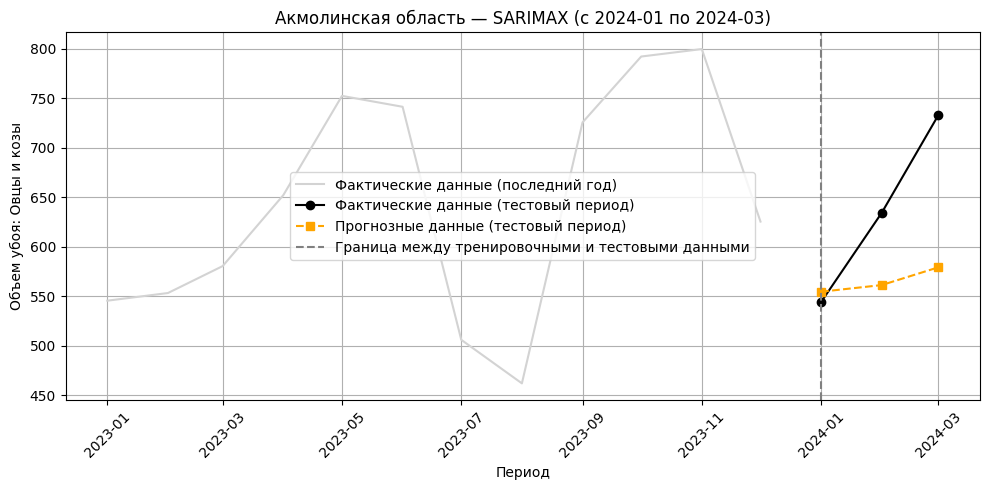

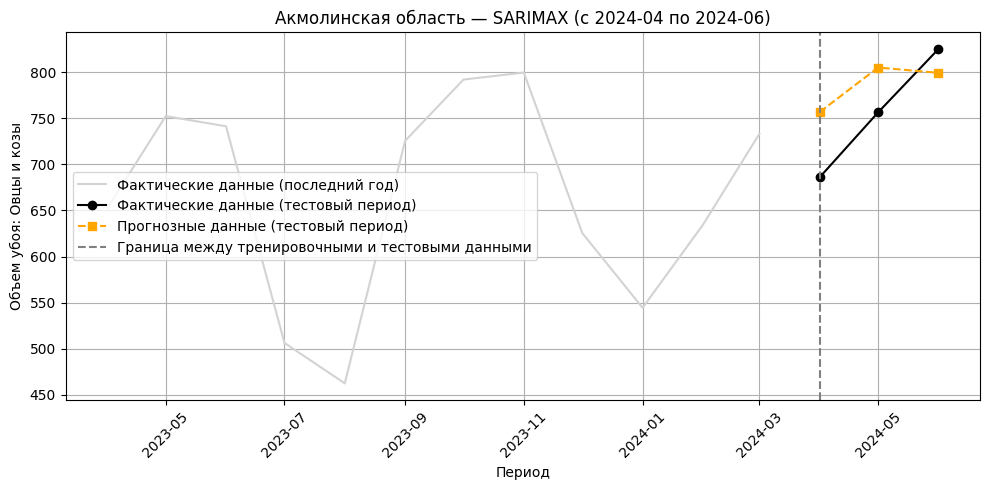

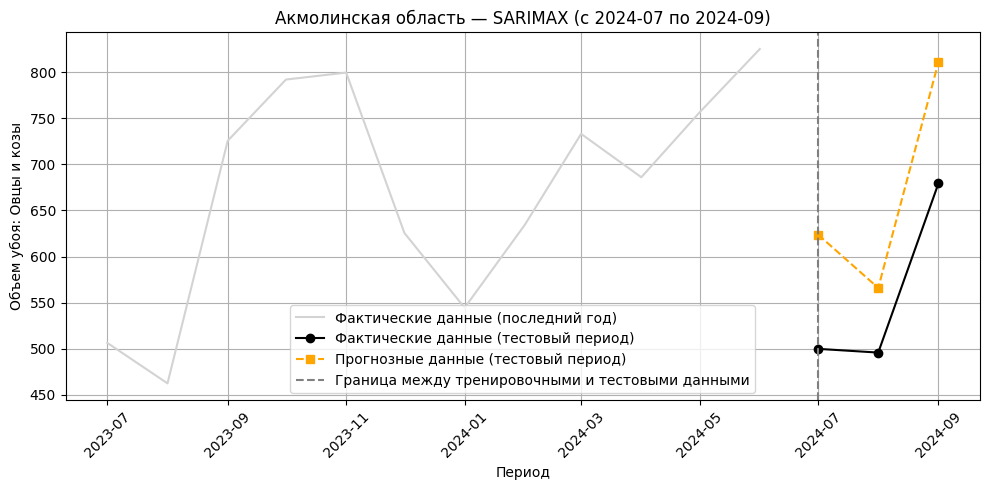

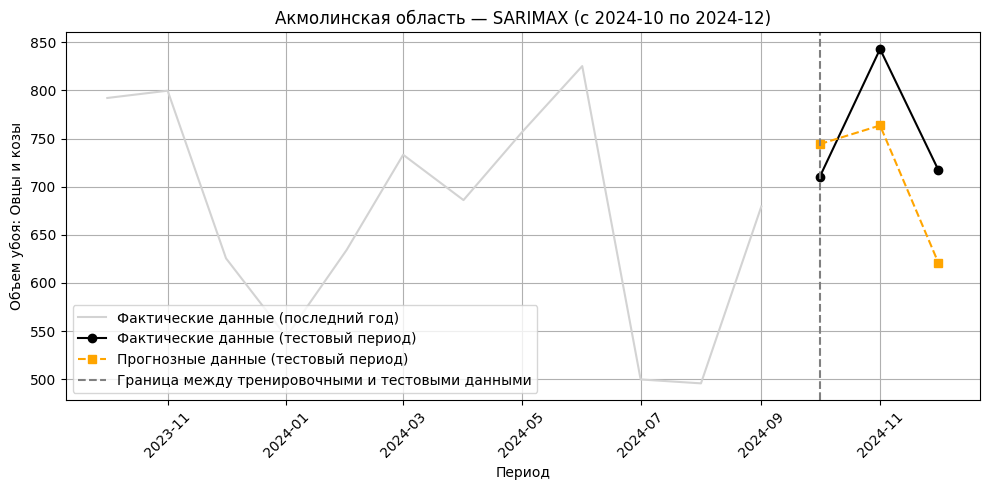

In [ ]:
# results = []

# start_dates = ["2024-01", "2024-04", "2024-07", "2024-10"]

# for start in start_dates:
#     test_start = pd.to_datetime(start)
#     test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)

#     # Split
#     train_df = df[df["Период"] < test_start]
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

#     y_train = train_df[target].reset_index(drop=True)
#     y_test = test_df[target].reset_index(drop=True)

#     exog_train = train_df[features].reset_index(drop=True)
#     exog_test = test_df[features].reset_index(drop=True)

#     try:
#         model = SARIMAX(
#             endog=y_train,
#             exog=exog_train,
#             order=(3, 1, 0),
#             seasonal_order=(1, 0, 1, 12),
#             enforce_stationarity=False,
#             enforce_invertibility=False
#         ).fit(disp=False)

#         forecast_res = model.get_forecast(steps=3, exog=exog_test)
#         forecast = forecast_res.predicted_mean.reset_index(drop=True)

#         rmse = np.sqrt(mean_squared_error(y_test, forecast))
#         mae = mean_absolute_error(y_test, forecast)
#         mape = (np.abs((y_test - forecast) / y_test).mean()) * 100

#         results.append({
#             "Test period": f"{start} to {test_end.strftime('%Y-%m')}",
#             "RMSE": rmse,
#             "MAE": mae,
#             "MAPE (%)": mape,
#             "SARIMA order": model.model_orders["ar"],
#             "Seasonal order": model.model_orders.get("seasonal_ar", None)
#         })

#         # Plot
#         plt.figure(figsize=(10, 5))
#         last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#         plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#         plt.plot(test_df["Период"], y_test, marker="o", color="black", label="Фактические данные (тестовый период)")
#         plt.plot(test_df["Период"], forecast, marker="s", linestyle="--", color="orange", label="Прогнозные данные (тестовый период)")
#         plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#         plt.title(f"Акмолинская область — SARIMAX (с {start} по {test_end.strftime('%Y-%m')})")
#         plt.xlabel("Период")
#         plt.ylabel("Объем убоя: Овцы и козы")
#         plt.legend()
#         plt.grid(True)
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()

#     except Exception as e:
#         print(f"⚠️ Ошибка в периоде {start}: {e}")


In [ ]:
# # Вывод метрик для SARIMAX
# results_df = pd.DataFrame(results)

# # Средние значения по метрикам
# avg_metrics = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg_metrics["Test period"] = "Average"
# avg_metrics["SARIMA order"] = ""
# avg_metrics["Seasonal order"] = ""

# # Добавим строку со средними значениями
# results_df = pd.concat([results_df, pd.DataFrame([avg_metrics])], ignore_index=True)

# # Вывод
# print(results_df)



          Test period        RMSE         MAE   MAPE (%) SARIMA order  \
0  2024-01 to 2024-03   98.461145   79.062209  11.463866            3   
1  2024-04 to 2024-06   51.806621   48.447788   6.628976            3   
2  2024-07 to 2024-09  112.048404  108.655462  19.458650            3   
3  2024-10 to 2024-12   74.757523   69.984044   9.222765            3   
4             Average   84.268423   76.537376  11.693564                

  Seasonal order  
0             12  
1             12  
2             12  
3             12  
4                 


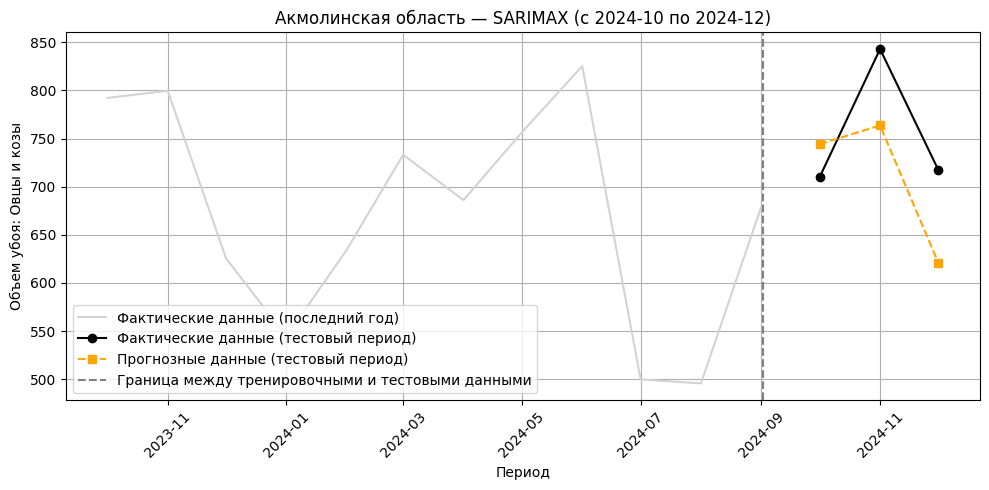

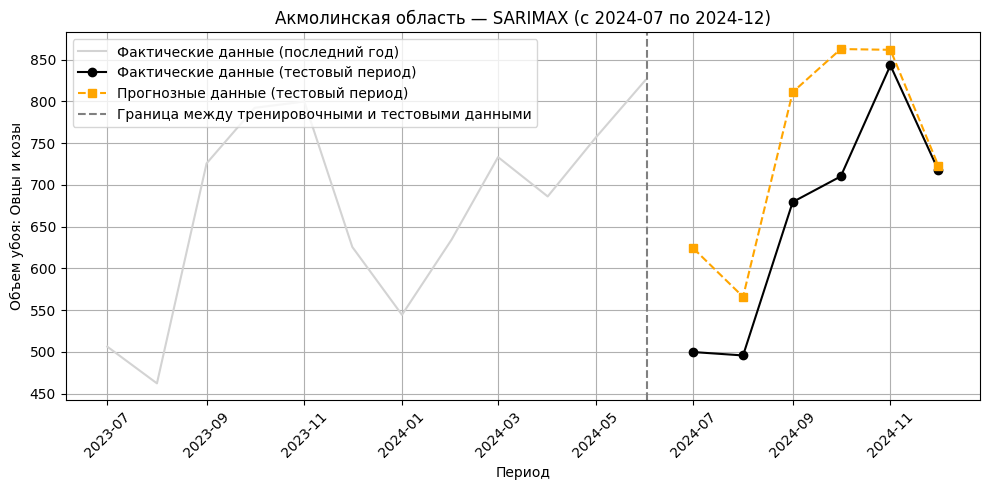

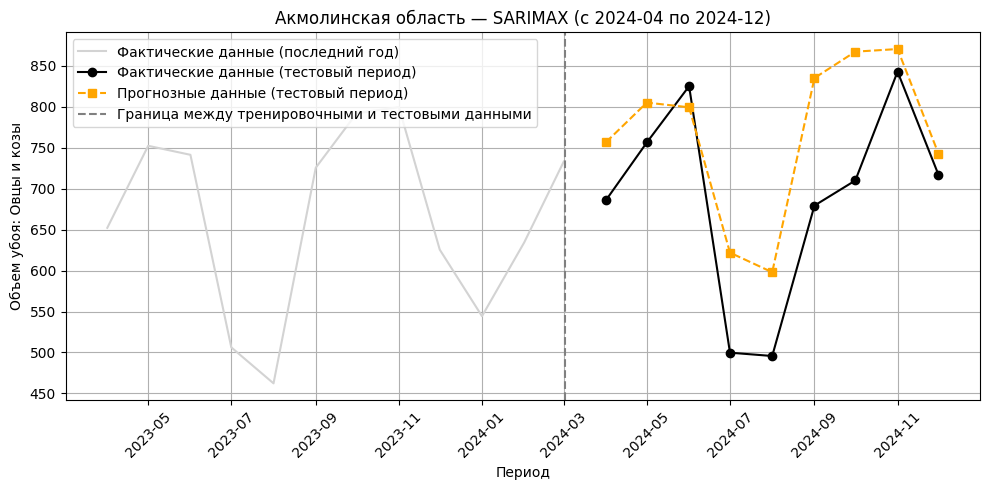

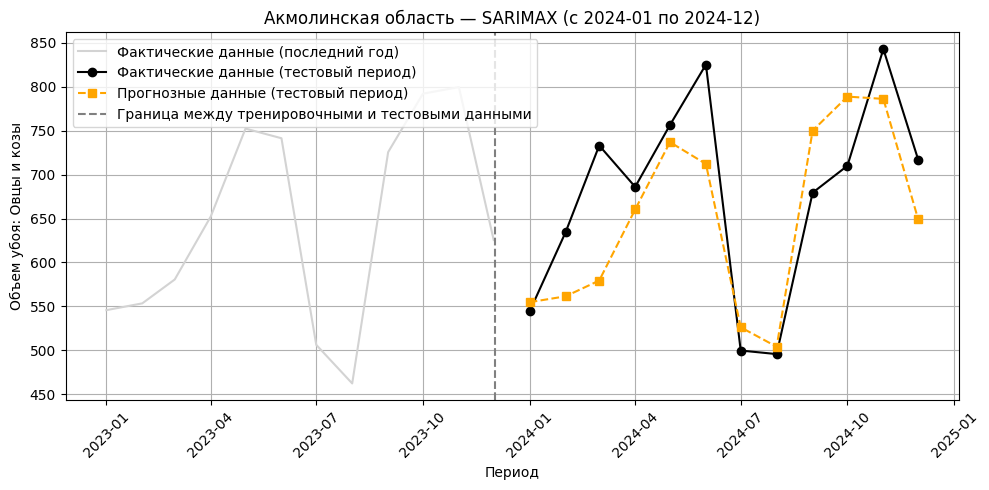

In [ ]:
# results = []

# horizons = [3, 6, 9, 12]

# for horizon in horizons:
#     # test_start = pd.to_datetime(start)
#     # test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)
#     test_end = pd.to_datetime("2024-12")
#     test_start = test_end - pd.DateOffset(months=horizon) + pd.DateOffset(days=1)

#     # Split
#     train_df = df[df["Период"] < test_start]
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

#     y_train = train_df[target].reset_index(drop=True)
#     y_test = test_df[target].reset_index(drop=True)

#     exog_train = train_df[features].reset_index(drop=True)
#     exog_test = test_df[features].reset_index(drop=True)

#     try:
#         model = SARIMAX(
#             endog=y_train,
#             exog=exog_train,
#             order=(3, 1, 0),
#             seasonal_order=(1, 0, 1, 12),
#             enforce_stationarity=False,
#             enforce_invertibility=False
#         ).fit(disp=False)

#         forecast_res = model.get_forecast(steps=horizon, exog=exog_test)
#         forecast = forecast_res.predicted_mean.reset_index(drop=True)

#         rmse = np.sqrt(mean_squared_error(y_test, forecast))
#         mae = mean_absolute_error(y_test, forecast)
#         mape = (np.abs((y_test - forecast) / y_test).mean()) * 100

#         results.append({
#             "Test period": f"{(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} to {test_end.strftime('%Y-%m')}",
#             "RMSE": rmse,
#             "MAE": mae,
#             "MAPE (%)": mape,
#             "SARIMA order": model.model_orders["ar"],
#             "Seasonal order": model.model_orders.get("seasonal_ar", None)
#         })

#         # Plot
#         plt.figure(figsize=(10, 5))
#         last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#         plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#         plt.plot(test_df["Период"], y_test, marker="o", color="black", label="Фактические данные (тестовый период)")
#         plt.plot(test_df["Период"], forecast, marker="s", linestyle="--", color="orange", label="Прогнозные данные (тестовый период)")
#         plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#         plt.title(f"Акмолинская область — SARIMAX (с {(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
#         plt.xlabel("Период")
#         plt.ylabel("Объем убоя: Овцы и козы")
#         plt.legend()
#         plt.grid(True)
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()

#     except Exception as e:
#         print(f"⚠️ Ошибка в периоде {start}: {e}")


In [ ]:
# # Вывод метрик для SARIMAX
# results_df = pd.DataFrame(results)

# # Средние значения по метрикам
# avg_metrics = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg_metrics["Test period"] = "Average"
# avg_metrics["SARIMA order"] = ""
# avg_metrics["Seasonal order"] = ""

# # Добавим строку со средними значениями
# results_df = pd.concat([results_df, pd.DataFrame([avg_metrics])], ignore_index=True)

# # Вывод
# print(results_df)

          Test period        RMSE        MAE   MAPE (%) SARIMA order  \
0  2024-10 to 2024-12   74.757523  69.984044   9.222765            3   
1  2024-07 to 2024-12  101.078858  83.765691  13.804459            3   
2  2024-04 to 2024-12   96.582370  81.839026  12.995950            3   
3  2024-01 to 2024-12   72.311179  58.720825   8.260532            3   
4             Average   86.182482  73.577396  11.070926                

  Seasonal order  
0             12  
1             12  
2             12  
3             12  
4                 


#### Prophet

16:53:59 - cmdstanpy - INFO - Chain [1] start processing
16:53:59 - cmdstanpy - INFO - Chain [1] done processing


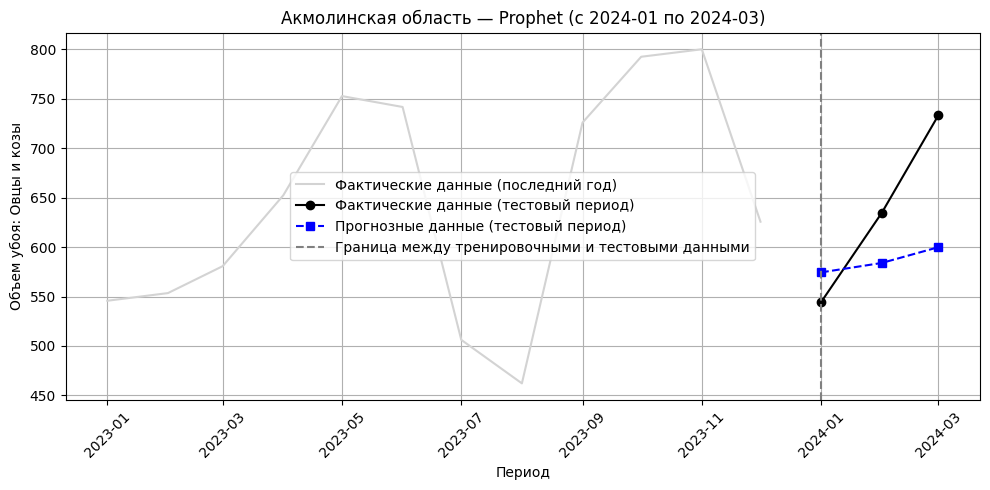

16:53:59 - cmdstanpy - INFO - Chain [1] start processing
16:53:59 - cmdstanpy - INFO - Chain [1] done processing


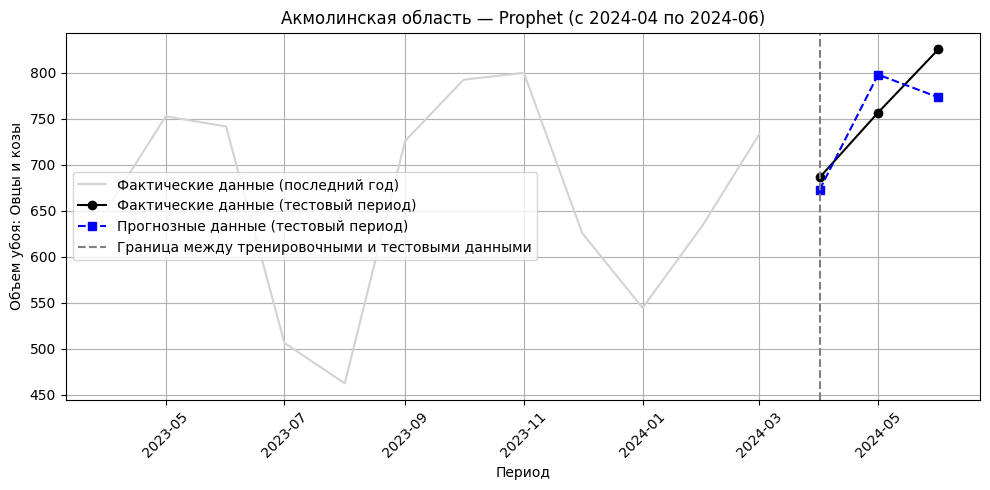

16:54:00 - cmdstanpy - INFO - Chain [1] start processing
16:54:00 - cmdstanpy - INFO - Chain [1] done processing


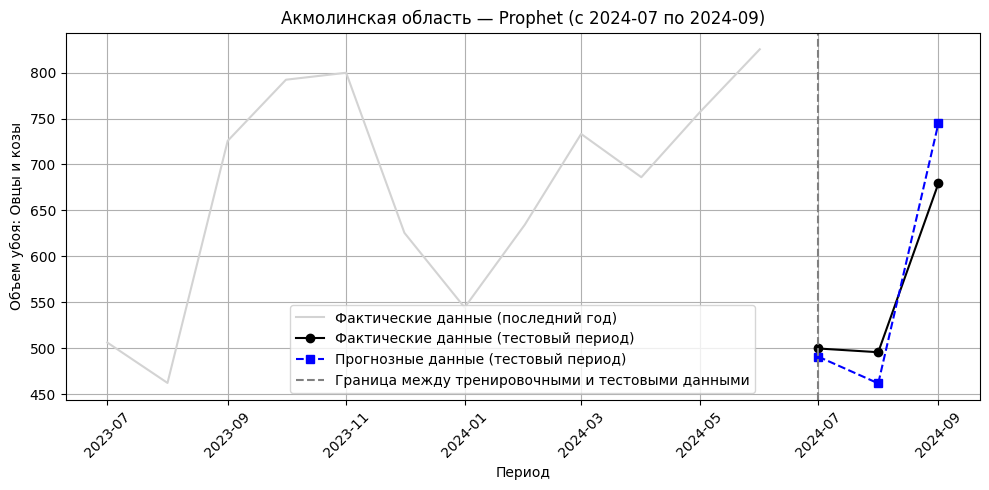

16:54:00 - cmdstanpy - INFO - Chain [1] start processing
16:54:00 - cmdstanpy - INFO - Chain [1] done processing


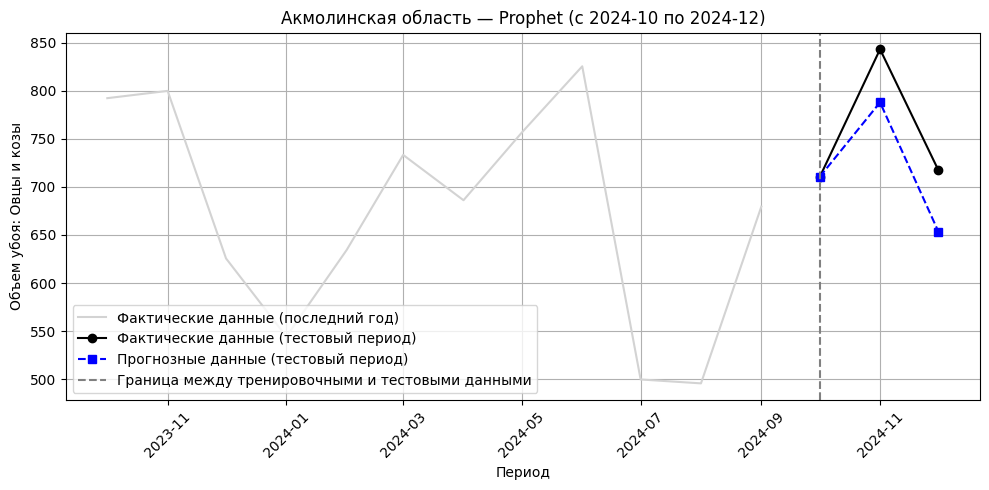

In [ ]:
# results = []

# # Define 4 test periods
# start_dates = ["2024-01", "2024-04", "2024-07", "2024-10"]

# for start in start_dates:
#     test_start = pd.to_datetime(start)
#     test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)

#     # Train/test split
#     train_df = df[df["Период"] < test_start].copy()
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)].copy()

#     # Prophet format
#     prophet_train = train_df[["Период", target]].rename(columns={"Период": "ds", target: "y"})
#     prophet_test = test_df[["Период", target]].rename(columns={"Период": "ds", target: "y"})

#     # Initialize Prophet
#     model = Prophet()

#     # Optional: add regressors
#     # model.add_regressor("Температура_t-1")
#     # prophet_train["Температура_t-1"] = train_df["Температура_t-1"].values
#     # prophet_test["Температура_t-1"] = test_df["Температура_t-1"].values

#     # Fit
#     model.fit(prophet_train)

#     # Create future dataframe
#     future = model.make_future_dataframe(periods=3, freq="M")
#     forecast = model.predict(future)
# # forecast
# # prophet_test

#     # Extract forecast for test period only
#     forecast_test = forecast[forecast["ds"].isin(prophet_test["ds"] - pd.DateOffset(days=1))].copy()
#     y_pred = forecast_test["yhat"].values
#     y_true = prophet_test["y"].values

#     # Evaluate
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     mae = mean_absolute_error(y_true, y_pred)
#     mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100

#     results.append({
#         "Test period": f"{start} to {test_end.strftime('%Y-%m')}",
#         "RMSE": rmse,
#         "MAE": mae,
#         "MAPE (%)": mape
#     })

#     # Plot
#     plt.figure(figsize=(10, 5))
#     last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#     plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#     plt.plot(test_df["Период"], test_df[target], marker="o", color="black", label="Фактические данные (тестовый период)")
#     plt.plot(test_df["Период"], y_pred, marker="s", linestyle="--", color="blue", label="Прогнозные данные (тестовый период)")
#     plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#     plt.title(f"Акмолинская область — Prophet (с {start} по {test_end.strftime('%Y-%m')})")
#     plt.xlabel("Период")
#     plt.ylabel("Объем убоя: Овцы и козы")
#     plt.legend()
#     plt.grid(True)
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()



In [ ]:
# results_df = pd.DataFrame(results)
# avg = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg["Test period"] = "Average"
# results_df = pd.concat([results_df, pd.DataFrame([avg])], ignore_index=True)
# print(results_df)

          Test period       RMSE        MAE   MAPE (%)
0  2024-01 to 2024-03  84.169871  71.336335  10.561117
1  2024-04 to 2024-06  39.188649  35.579463   4.570703
2  2024-07 to 2024-09  42.876492  36.059870   6.079085
3  2024-10 to 2024-12  48.743841  39.802398   5.166620
4             Average  53.744713  45.694516   6.594381


16:54:01 - cmdstanpy - INFO - Chain [1] start processing
16:54:01 - cmdstanpy - INFO - Chain [1] done processing


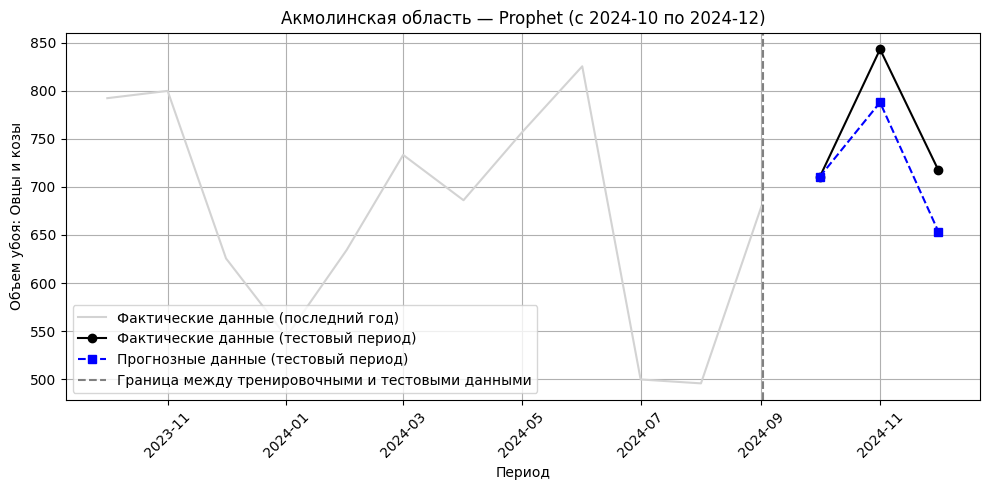

16:54:01 - cmdstanpy - INFO - Chain [1] start processing
16:54:01 - cmdstanpy - INFO - Chain [1] done processing


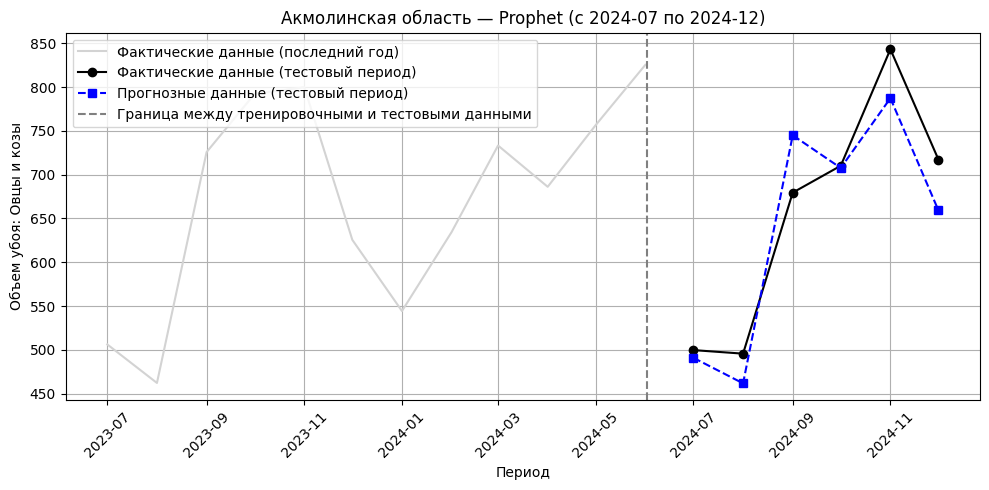

16:54:02 - cmdstanpy - INFO - Chain [1] start processing
16:54:02 - cmdstanpy - INFO - Chain [1] done processing


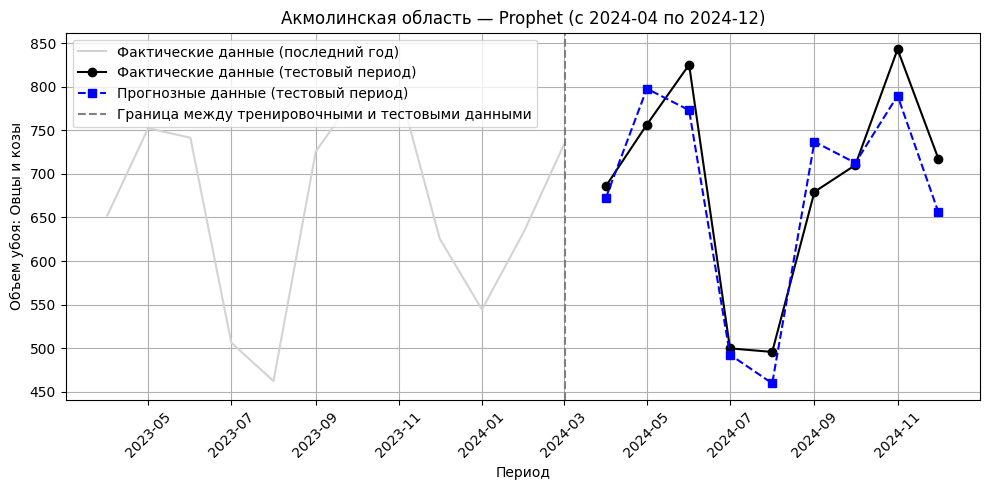

16:54:02 - cmdstanpy - INFO - Chain [1] start processing
16:54:02 - cmdstanpy - INFO - Chain [1] done processing


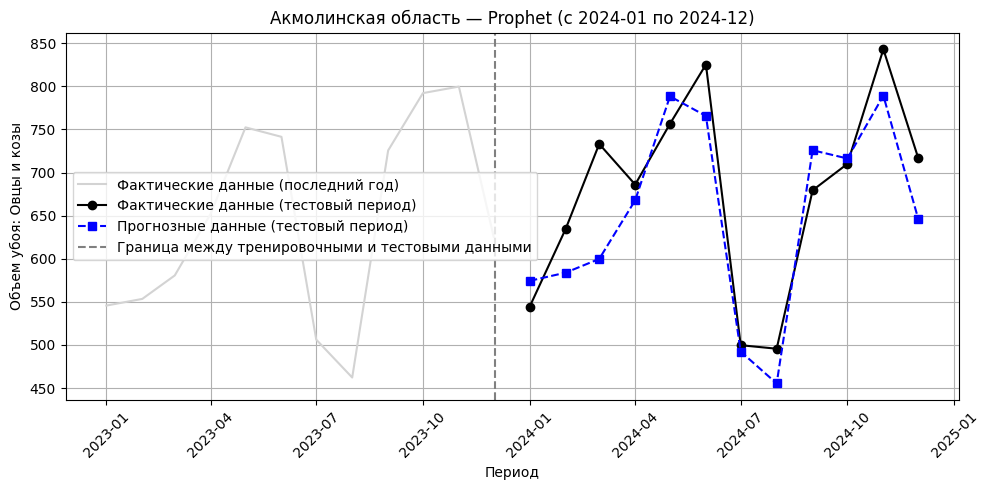

In [ ]:
# horizons = [3, 6, 9, 12]
# results = []

# for horizon in horizons:

#     # Define train/test split
#     test_end = pd.to_datetime("2024-12")
#     test_start = test_end - pd.DateOffset(months=horizon) + pd.DateOffset(days=1)

#     train_df = df[df["Период"] < test_start].copy()
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)].copy()

#     # Prophet format
#     prophet_train = train_df[["Период", target]].rename(columns={"Период": "ds", target: "y"})
#     prophet_test = test_df[["Период", target]].rename(columns={"Период": "ds", target: "y"})

#     # Fit Prophet
#     model = Prophet()
#     model.fit(prophet_train)

#     # Forecast
#     future = model.make_future_dataframe(periods=horizon, freq="M")
#     forecast = model.predict(future)

#     # Extract matching forecasted months
#     forecast_test = forecast[forecast["ds"].isin(prophet_test["ds"] - pd.DateOffset(days=1))].copy()
#     y_pred = forecast_test["yhat"].values
#     y_true = prophet_test["y"].values

#     # Evaluation
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     mae = mean_absolute_error(y_true, y_pred)
#     mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100

#     results.append({
#         "Test period": f"{(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} to {test_end.strftime('%Y-%m')}",
#         "RMSE": rmse,
#         "MAE": mae,
#         "MAPE (%)": mape
#     })

#     # Plot
#     plt.figure(figsize=(10, 5))
#     last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#     plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#     plt.plot(test_df["Период"], test_df[target], marker="o", color="black", label="Фактические данные (тестовый период)")
#     plt.plot(test_df["Период"], y_pred, marker="s", linestyle="--", color="blue", label="Прогнозные данные (тестовый период)")
#     plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#     plt.title(f"Акмолинская область — Prophet (с {(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
#     plt.xlabel("Период")
#     plt.ylabel("Объем убоя: Овцы и козы")
#     plt.legend()
#     plt.grid(True)
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()




In [ ]:
# # Summary table
# results_df = pd.DataFrame(results)
# avg_row = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# print(results_df)

          Test period       RMSE        MAE  MAPE (%)
0  2024-10 to 2024-12  48.743841  39.802398  5.166620
1  2024-07 to 2024-12  44.738271  37.431366  5.551629
2  2024-04 to 2024-12  42.003940  36.070369  5.124235
3  2024-01 to 2024-12  56.210914  45.719187  6.612248
4                 NaN  47.924242  39.755830  5.613683


strength of correlation:
https://link.springer.com/article/10.1057/jt.2009.5#
https://resources.nu.edu/statsresources/correlation